# Multi-session BCI QC Summary — Multi-group

Aggregates BCI sessions from one or more experimental groups and produces
summary figures comparing groups.

| Output | Description |
|--------|-------------|
| **4-panel** | Hit-rate deviation · CN directionality · Peri-reward dF/F · TTR epoch OLS |
| **Fig 2** | Peak CN peri-reward activity per trial (trial-aligned + threshold-change-aligned) |
| **Fig 3** | Mean z-scored CN activity across sessions (smoothed, per group) |
| **Fig 4** | CN activity heatmaps — trial-start aligned + reward-aligned (sessions stacked by group) |
| **Fig 5** | Local max learning metric — best WIN_SIZE-trial slope of CN activity (per group) |

Between-group statistical tests annotated on every panel/figure:
Mann-Whitney U (2 groups) or Kruskal-Wallis (≥ 3 groups).

**Data-dict structure (verified):**
- `F` → `(n_timepoints, n_ROIs, n_trials)` dF/F, already neuropil-corrected
- `df_closedloop` → `(n_ROIs, n_frames)` continuous dF/F for peri-reward
- `reward_time[i]` → `array([ttr_s])` for hits, `array([])` for misses
- `BCI_thresholds[0]` → trial timeout in frames; `[1]` → fluorescence threshold


In [1]:
import os, json, re, sys, logging, traceback, subprocess, warnings
from itertools import combinations
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

sys.path.insert(0, "/code")
import extract_scanimage_metadata
import data_dict_create_module_bruker as ddc

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
%matplotlib inline
print("Imports OK")


could not import s2p
Imports OK


In [2]:
# ── Analysis parameters ───────────────────────────────────────────────────────
HIT_WINDOW   = 10          # trials: moving-avg window for actual hit rate   (Panel 1)
CN_SMOOTH    = 10          # trials: smoothing window before CN derivative   (Panel 2)
BASELINE_SEC = (-5., -4.)  # sec rel. to reward: dF/F₀ baseline window      (Panel 3)
PLOT_SEC     = (-5.,  5.)  # sec rel. to reward: display window              (Panel 3)
CN_SD_WINDOW = 20          # trials: rolling SD window (single-epoch fallback)
MIN_SESSIONS = 3           # minimum sessions per group at any trial index (Panels 1, Figs 2–3)

# DATE_FILTER = "2026-06-04"   # restrict discovery to one date string, or None for all
DATE_FILTER  = None

# ── Experimental groups ───────────────────────────────────────────────────────
# Map each group label to the list of animal subject-ID strings exactly as they
# appear in asset names:  single-plane-ophys_<subject>_<date>_...
GROUPS = {
    "Ctrl":   ["820614", "824946", "820615", "855519"],   # ← replace with your actual IDs
    "LC-KO": ["857094", "857095", '849680'],
    #"VTA-KO": ["850381", "850378"],
}

# Optional: pin specific hex/named colors. None = auto-assign from tab10.
GROUP_COLORS = None   # e.g. {"Control": "steelblue", "Treatment": "darkorange"}


In [3]:
def _json_ok(line):
    try:
        json.loads(line); return True
    except json.JSONDecodeError:
        return False


def find_pair_in_data(subject: str, date: str):
    """Return (raw, proc, proc_root) Paths for a given subject + date."""
    asset_prefix = f"single-plane-ophys_{subject}_{date}_"
    attached = sorted(Path("/data").iterdir())
    raws  = [p for p in attached
             if p.name.startswith(asset_prefix) and "_processed_" not in p.name]
    procs = [p for p in attached
             if p not in raws and subject in p.name and date in p.name]
    if not raws:
        raise RuntimeError(f"No raw asset for {subject}/{date}")
    if len(raws) > 1:
        raise RuntimeError(f"Multiple raw assets for {subject}/{date}: {[r.name for r in raws]}")
    raw = raws[0]
    if not procs:
        raise RuntimeError(f"No processed asset for {subject}/{date}")
    def _ts(p):
        m = re.search(r"_processed_(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})", p.name)
        return m.group(1) if m else ""
    proc = sorted(procs, key=_ts, reverse=True)[0]
    if (proc / "extraction").is_dir():
        proc_root = proc
    else:
        candidates = [c for c in proc.iterdir()
                      if c.is_dir() and (c / "extraction").is_dir()]
        if not candidates:
            raise RuntimeError(f"No extraction/ inside {proc.name}")
        proc_root = candidates[0]
    return raw, proc, proc_root


def build_workspace(subject: str, date: str, target_stem: str) -> Path:
    """Build a scratch workspace for ddc.main and return the pophys Path."""
    session_tag = f"{subject}_{date}_{target_stem}"
    workspace   = Path(f"/scratch/qc_{session_tag}")
    pophys      = workspace / "pophys"

    raw, _, proc_root = find_pair_in_data(subject, date)
    extraction = proc_root / "extraction"
    mc         = proc_root / "motion_correction"

    with open(mc / "epoch_locations.json") as f:
        epoch_locations = json.load(f)
    with open(mc / "trial_locations.json") as f:
        trial_locations = json.load(f)

    if target_stem not in epoch_locations:
        base       = target_stem.rstrip("0123456789") or target_stem
        candidates = sorted(k for k in epoch_locations if base in k)
        if not candidates:
            raise RuntimeError(
                f"Epoch {target_stem!r} not found. Available: {list(epoch_locations)}")
        target_stem = base if base in epoch_locations else candidates[0]
        print(f"  NOTE: using epoch {target_stem!r}")

    target_start, target_end = epoch_locations[target_stem]
    subprocess.run(["rm", "-rf", str(workspace)], check=False)
    pophys.mkdir(parents=True)

    behavior_src = raw / "behavior"
    behavior_dst = workspace / "behavior"
    for src_path in behavior_src.rglob("*"):
        rel      = src_path.relative_to(behavior_src)
        dst_path = behavior_dst / rel
        if src_path.is_dir():
            dst_path.mkdir(parents=True, exist_ok=True)
        elif src_path.suffix == ".json" and rel.parts[0] == "SoftwareEvents":
            lines = src_path.read_text(errors="replace").splitlines()
            good  = [l for l in lines if l.strip() and _json_ok(l)]
            dst_path.write_text("\n".join(good) + "\n")
        else:
            if not dst_path.exists():
                dst_path.symlink_to(src_path)

    target_tifs = sorted(
        name for name, (s, e) in trial_locations.items()
        if name.startswith(f"{target_stem}_") and s >= target_start and e <= target_end
    )
    frames_per_file = [
        trial_locations[n][1] - trial_locations[n][0] + 1 for n in target_tifs
    ]
    for f in (raw / "pophys").iterdir():
        if (f.is_file() and f.suffix not in (".tif", ".stim")
                and f.name.startswith(f"{target_stem}_")):
            tgt = pophys / f.name
            if not tgt.exists():
                tgt.symlink_to(f)

    bci_dir     = pophys / "suite2p_BCI" / "plane0"
    bci_dir.mkdir(parents=True)
    frame_slice = slice(target_start, target_end + 1)
    for fname in ["F", "Fneu", "spks"]:
        src = extraction / f"{fname}.npy"
        if src.exists():
            arr = np.load(src, mmap_mode="r")
            np.save(bci_dir / f"{fname}.npy", arr[:, frame_slice])
            del arr
    for fname in ["stat.npy", "iscell.npy"]:
        src = extraction / fname
        if src.exists():
            (bci_dir / fname).symlink_to(src)

    ops = np.load(extraction / "ops.npy", allow_pickle=True).tolist()
    ops["frames_per_file"] = frames_per_file
    np.save(bci_dir / "ops.npy", ops)

    first_tif = raw / "pophys" / target_tifs[0]
    siHeader  = extract_scanimage_metadata.extract_scanimage_metadata(str(first_tif))
    siHeader["siBase"]      = {0: target_stem, 1: "", 2: "spont_pre"}
    siHeader["savefolders"] = {0: target_stem, 1: "spont", 2: "spont_post",
                                3: "spont_pre", 4: "spont_post"}
    np.save(bci_dir / "siHeader.npy", siHeader)

    print(f"  workspace: qc_{session_tag}  "
          f"({len(target_tifs)} TIFFs, {sum(frames_per_file)} frames)")
    return pophys


In [4]:
def _best_bci_stem(proc_root):
    """Return the bci stem with the most trial files (e.g. bci2 over bci)."""
    trial_json = proc_root / "motion_correction" / "trial_locations.json"
    if not trial_json.exists():
        return "bci"
    with open(trial_json) as f:
        trial_locs = json.load(f)
    stem_counts = {}
    for name in trial_locs:
        parts = name.rsplit("_", 1)
        if len(parts) == 2:
            stem = parts[0]
            if re.match(r"bci\d*$", stem):
                stem_counts[stem] = stem_counts.get(stem, 0) + 1
    if not stem_counts:
        return "bci"
    best = max(stem_counts, key=stem_counts.get)
    if best != "bci":
        print(f"  {best!r} selected over 'bci' ({stem_counts})")
    return best


attached = sorted(Path("/data").iterdir())
print(f"Attached assets in /data ({len(attached)}):")
for p in attached:
    print(f"  {p.name}")

n_groups = len(GROUPS)
if GROUP_COLORS is not None:
    _palette = [GROUP_COLORS[g] for g in GROUPS]
else:
    _palette = [plt.cm.tab10(i) for i in range(n_groups)]
GROUP_COLOR_MAP = {name: col for name, col in zip(GROUPS.keys(), _palette)}

raws_all = [p for p in attached
            if p.name.startswith("single-plane-ophys_")
            and "_processed_" not in p.name]

targets_by_group = {g: [] for g in GROUPS}
for raw in raws_all:
    m = re.match(r"single-plane-ophys_(\d+)_(\d{4}-\d{2}-\d{2})_", raw.name)
    if not m:
        continue
    subject, date = m.group(1), m.group(2)
    if DATE_FILTER and date != DATE_FILTER:
        continue
    matched_group = None
    for group_name, ids in GROUPS.items():
        if subject in ids:
            matched_group = group_name
            break
    if matched_group is None:
        continue
    try:
        _, _, proc_root = find_pair_in_data(subject, date)
        stem = _best_bci_stem(proc_root)
        targets_by_group[matched_group].append((subject, date, stem))
    except Exception as e:
        print(f"  Skipping {subject}/{date}: {e}")

print(f"\nDate filter: {DATE_FILTER or 'none (all dates)'}")
for g, targets in targets_by_group.items():
    print(f"\nGroup '{g}'  (n = {len(targets)} sessions)  color = {GROUP_COLOR_MAP[g]}:")
    for subj, dt, stem in targets:
        print(f"  {subj}  {dt}  stem={stem}")


Attached assets in /data (132):
  single-plane-ophys_820614_2026-05-13_12-43-55
  single-plane-ophys_820614_2026-05-13_12-43-55_processed_2026-05-30_02-13-12
  single-plane-ophys_820614_2026-05-15_10-48-16
  single-plane-ophys_820614_2026-05-18_16-52-23
  single-plane-ophys_820614_2026-05-18_16-52-23_processed_2026-05-30_02-17-36
  single-plane-ophys_820614_2026-05-20_10-17-01
  single-plane-ophys_820614_2026-05-20_10-17-01_processed_2026-05-30_02-57-06
  single-plane-ophys_820614_2026-05-21_11-02-24
  single-plane-ophys_820614_2026-05-21_11-02-24_processed_2026-05-30_01-21-24
  single-plane-ophys_820614_2026-05-22_10-24-33
  single-plane-ophys_820614_2026-05-22_10-24-33_processed_2026-05-30_03-14-12
  single-plane-ophys_820614_2026-05-27_13-10-42
  single-plane-ophys_820614_2026-05-27_13-10-42_processed_2026-05-28_04-20-11
  single-plane-ophys_820614_2026-05-28_09-50-38
  single-plane-ophys_820614_2026-05-28_09-50-38_processed_2026-05-28_19-22-48
  single-plane-ophys_820614_2026-05-29

In [5]:
# ── OPTIONAL — uncomment and run once to inspect a session's data dict ─────────
#
# _group  = list(GROUPS)[0]
# _subj, _date, _stem = targets_by_group[_group][0]
# _pophys = build_workspace(_subj, _date, _stem)
# _data   = ddc.main(str(_pophys) + "/")
# print(f"\nData dict keys for {_subj} / {_date}:")
# for k, v in sorted(_data.items()):
#     if isinstance(v, np.ndarray):
#         print(f"  {k!r:35s} ndarray    shape={v.shape}  dtype={v.dtype}")
#     elif hasattr(v, '__len__'):
#         print(f"  {k!r:35s} {type(v).__name__:12s} len={len(v)}")
#     else:
#         print(f"  {k!r:35s} {type(v).__name__:12s} = {repr(v)[:60]}")
# del _data


In [6]:
def moving_average(arr, window):
    arr = np.asarray(arr, dtype=float)
    out = np.empty(len(arr))
    for i in range(len(arr)):
        out[i] = np.mean(arr[max(0, i - window + 1):i + 1])
    return out


def pool_traces(traces):
    """Stack ragged 1-D traces → (mean, sem, n_valid), NaN-padded to max length."""
    max_len = max(len(t) for t in traces)
    mat     = np.full((len(traces), max_len), np.nan)
    for i, t in enumerate(traces):
        mat[i, :len(t)] = t
    mean  = np.nanmean(mat, axis=0)
    n_val = np.sum(~np.isnan(mat), axis=0)
    sem   = np.where(n_val > 1,
                     np.nanstd(mat, axis=0, ddof=1) / np.sqrt(n_val),
                     np.nan)
    return mean, sem, n_val


def cn_directionality(trace, smooth_window):
    trace = np.asarray(trace, dtype=float)
    if len(trace) < smooth_window + 2:
        return np.nan
    nans = np.isnan(trace)
    if nans.all():
        return np.nan
    if nans.any():
        x = np.arange(len(trace))
        trace = np.interp(x, x[~nans], trace[~nans])
    smoothed = np.convolve(trace, np.ones(smooth_window) / smooth_window, mode='valid')
    deriv = np.diff(smoothed)
    above = deriv[deriv > 0].sum()
    below = np.abs(deriv[deriv < 0]).sum()
    total = above + below
    return 0.0 if total == 0 else (above - below) / total


def peri_reward_from_continuous(cn_trace, reward_frame_indices, fs,
                                 baseline_sec, plot_sec):
    n      = len(cn_trace)
    b0, b1 = int(baseline_sec[0] * fs), int(baseline_sec[1] * fs)
    p0, p1 = int(plot_sec[0] * fs),     int(plot_sec[1] * fs)
    n_plot = p1 - p0
    trials = []
    for rf in reward_frame_indices:
        if np.isnan(rf):
            continue
        rf = int(rf)
        bs, be = rf + b0, rf + b1
        ps, pe = rf + p0, rf + p1
        if bs < 0 or be > n or ps < 0 or pe > n:
            continue
        F0 = float(np.mean(cn_trace[bs:be]))
        t  = cn_trace[ps:pe] - F0
        if len(t) == n_plot:
            trials.append(t)
    return np.mean(trials, axis=0) if trials else None


def ttr_constrained_slope(ttr_real, ttr_expected):
    ttr_real     = np.asarray(ttr_real,     dtype=float)
    ttr_expected = np.asarray(ttr_expected, dtype=float)
    if ttr_expected.ndim == 0 or ttr_expected.size == 1:
        ttr_expected = np.full(len(ttr_real), float(ttr_expected.flat[0]))
    safe_exp = np.where(ttr_expected > 0, ttr_expected, np.nan)
    ratio    = ttr_real / safe_exp
    x_all    = np.arange(len(ratio), dtype=float)
    hit_mask = ~np.isnan(ratio)
    x_hit    = x_all[hit_mask]
    y_hit    = ratio[hit_mask] - 1.0
    denom    = float(np.dot(x_hit, x_hit))
    slope    = float(np.dot(x_hit, y_hit)) / denom if denom > 0 else 0.0
    fitted   = 1.0 + slope * x_all
    return slope, ratio, fitted


def between_group_test(groups_values):
    """MWU (2 groups) or Kruskal-Wallis (3+) on per-session scalars.
    Returns (p_val, test_name, sig_string)."""
    arrays = [np.array([v for v in d if not np.isnan(v)], dtype=float)
              for d in groups_values]
    valid  = [a for a in arrays if len(a) > 0]
    if len(valid) < 2:
        return np.nan, 'N/A', 'N/A'
    try:
        if len(valid) == 2:
            _, p_val  = stats.mannwhitneyu(valid[0], valid[1], alternative='two-sided')
            test_name = 'MWU'
        else:
            _, p_val  = stats.kruskal(*valid)
            test_name = 'K-W'
    except Exception:
        return np.nan, 'N/A', 'N/A'
    sig = ('***' if p_val < 0.001 else '**' if p_val < 0.01
           else '*' if p_val < 0.05 else 'ns')
    return p_val, test_name, sig


In [7]:
def _zscore_trace(trace, rs, re):
    """Z-score a 1-D array to the baseline window [rs, re)."""
    mu    = float(np.nanmean(trace[rs:re]))
    sigma = float(np.nanstd( trace[rs:re]))
    return (trace - mu) / (sigma if sigma > 0 else 1.0)


records_by_group = {g: [] for g in GROUPS}

for group_name, targets in targets_by_group.items():
    print(f"\n{'═' * 60}")
    print(f"Group: {group_name}  ({len(targets)} sessions)")
    print(f"{'═' * 60}")

    for subject, date, target_stem in targets:
        label = f"{subject}  {date}"
        print(f"\n── {label} {'─' * max(1, 50 - len(label))}")
        try:
            pophys = build_workspace(subject, date, target_stem)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                data = ddc.main(str(pophys) + "/")

            # ── 1. Scalars ────────────────────────────────────────────────────
            dt_si  = float(data['dt_si'])
            fs     = 1.0 / dt_si
            cn_idx = int(np.asarray(data['conditioned_neuron'][0]).flat[0])

            # ── 2. Per-trial behavioral arrays ────────────────────────────────
            reward_arr  = data['reward_time']
            trial_start = np.array(data['trial_start'], dtype=float)

            tc_arr  = data['threshold_crossing_time']
            si_arr  = data['SI_start_times']
            rt_tc   = np.array([x[0] if x.size > 0 else np.nan for x in tc_arr]) - \
                      np.array([x[0] if x.size > 0 else np.nan for x in si_arr])
            hit      = (~np.isnan(rt_tc)).astype(float)
            ttr_real = rt_tc

            # ── 3. Expected TTR and expected hit rate ─────────────────────────
            thresh   = data['BCI_thresholds']
            k_upper  = np.diff(thresh[1, :])
            switches = np.concatenate(([0],
                         np.where((k_upper != 0) & (~np.isnan(k_upper)))[0]))
            upr = thresh[1, switches + 1]
            lwr = float(thresh[0, switches[0] + 1])

            first_epoch_end = int(switches[1]) if len(switches) > 1 else len(rt_tc)
            first_mean_rt   = float(np.nanmean(rt_tc[0:first_epoch_end]))

            ttr_expected  = np.full(len(rt_tc), np.nan)
            expected_rate = np.full(len(rt_tc), np.nan)
            for si in range(len(switches)):
                ep_s  = int(switches[si])
                ep_e  = int(switches[si + 1]) if si + 1 < len(switches) else len(rt_tc)
                alpha = ((upr[0] - lwr) / (upr[si] - lwr)
                         if (upr[si] - lwr) != 0 else 1.0)
                ttr_expected[ep_s:ep_e]  = first_mean_rt / alpha
                expected_rate[ep_s:ep_e] = float(
                    np.mean(rt_tc[0:first_epoch_end] / alpha < 10))

            # ── 4. CN activity per trial ──────────────────────────────────────
            cn_act = np.nanmean(data['F'][:, cn_idx, :], axis=0).copy()

            # ── 5. CN continuous trace ────────────────────────────────────────
            cn_continuous = np.array(data['df_closedloop'][cn_idx, :], dtype=float)

            # ── 6. Per-trial normalized CN matrix for heatmaps (Fig 4) ────────
            # F shape: (n_timepoints, n_ROIs, n_trials) — extract CN, normalise [0,1]
            F_cn       = data['F'][:, cn_idx, :]        # (n_timepoints, n_trials)
            F_min_sess = float(np.nanmin(F_cn))
            F_max_sess = float(np.nanmax(F_cn))
            F_rng_sess = F_max_sess - F_min_sess if F_max_sess > F_min_sess else 1.0
            F_norm_cn  = ((F_cn - F_min_sess) / F_rng_sess).astype(np.float32)

            cn_heat_trial = np.nanmax(F_norm_cn, axis=1).copy()  # (n_timepoints,) max over trials
            t_bci_arr     = data['t_bci'].copy()

            # Reward time within each trial (seconds) — used for reward-aligned heatmap
            rew_trial_sec = np.array([r[0] if r.size > 0 else np.nan
                                      for r in reward_arr])

            del data   # ← free ~2–3 GB

            # ── 7. Z-score CN activity to first-epoch baseline ────────────────
            cn_act_z = _zscore_trace(cn_act, 3, first_epoch_end)

            # ── 8. Reward frame indices ───────────────────────────────────────
            rew_sec       = np.array([r[0] if r.size > 0 else np.nan
                                      for r in reward_arr])
            reward_sec    = trial_start + np.where(np.isnan(rew_sec), np.nan, rew_sec)
            reward_frames = np.where(np.isnan(reward_sec), np.nan,
                                     np.round(reward_sec / dt_si))

            # ── Panel metrics ─────────────────────────────────────────────────
            hit_diff  = moving_average(hit, HIT_WINDOW) - expected_rate
            cn_metric = cn_directionality(cn_act[3:], CN_SMOOTH)
            peri      = peri_reward_from_continuous(
                cn_continuous, reward_frames, fs, BASELINE_SEC, PLOT_SEC)

            # ── Per-trial peri-reward mean (±0.5 s window, Fig 2) ─────────────
            half_win   = int(0.5 * fs)
            n_cn       = len(cn_continuous)
            peri_trial = np.full(len(hit), np.nan)
            for i, rf in enumerate(reward_frames):
                if np.isnan(rf):
                    continue
                rf = int(rf)
                ws, we = rf - half_win, rf + half_win
                if ws < 0 or we > n_cn:
                    continue
                peri_trial[i] = float(np.mean(cn_continuous[ws:we]))
            baseline_mean   = float(np.nanmean(peri_trial[0:9]))
            peri_trial_norm = (peri_trial - baseline_mean
                               if not np.isnan(baseline_mean) else peri_trial.copy())
            del cn_continuous

            slope, ttr_ratio, ttr_fitted = ttr_constrained_slope(ttr_real, ttr_expected)

            records_by_group[group_name].append(dict(
                label           = label,
                group           = group_name,
                hit_diff        = hit_diff,
                cn_metric       = cn_metric,
                cn_act          = cn_act,
                cn_act_z        = cn_act_z,
                peri_trace      = peri,
                peri_trial_norm = peri_trial_norm,
                ttr_ratio       = ttr_ratio,
                ttr_fitted      = ttr_fitted,
                slope           = slope,
                switches        = switches.tolist(),
                cn_heat_trial   = cn_heat_trial,
                F_norm_cn       = F_norm_cn,
                rew_trial_sec   = rew_trial_sec,
                t_bci           = t_bci_arr,
                dt_si           = dt_si,
                fs              = fs,
            ))

            n_hit = int(hit.sum())
            print(f"  OK — {len(hit)} trials | {n_hit} hits "
                  f"| CN metric = {cn_metric:+.3f} | slope = {slope:+.5f}/trial")

        except Exception as e:
            print(f"  SKIPPED: {e}")
            traceback.print_exc()

total_loaded  = sum(len(r) for r in records_by_group.values())
total_targets = sum(len(t) for t in targets_by_group.values())
print(f"\n{'=' * 60}")
print(f"Loaded {total_loaded} / {total_targets} sessions total")
for g, recs in records_by_group.items():
    print(f"  {g}: {len(recs)} / {len(targets_by_group[g])}")



════════════════════════════════════════════════════════════
Group: Ctrl  (33 sessions)
════════════════════════════════════════════════════════════

── 820614  2026-05-13 ────────────────────────────────


  workspace: qc_820614_2026-05-13_bci2  (130 TIFFs, 88460 frames)
[bci] keeping 6 iscell==0 ROI(s) within 10 px of CN: [460, 612, 920, 926, 1858, 1888]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
[bonsai] 133 Bonsai trials, 130 SI files, 130 matched
[MAIN] Non-photostim data saved as pickle: /scratch/qc_820614_2026-05-13_bci2/pophys/data_main_scratch_qc_820614_2026-05-13_bci2_BCI.npy
[MAIN] Non-photostim data saved as HDF5:   /scratch/qc_820614_2026-05-13_bci2/pophys/data_main_scratch_qc_820614_2026-05-13_bci2_BCI.h5
  OK — 130 trials | 118 hits | CN metric = +0.182 | slope = -0.00553/trial

── 820614  2026-05-18 ────────────────────────────────
  workspace: qc_820614_2026-05-18_bci  (87 TIFFs, 55157 frames)
[bci] keeping 4 iscell==0 ROI(s) within 10 px of CN: [1250, 1417, 2146, 2739]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
[bonsai] 88 Bonsai trials, 87 SI files, 87 matched
[MAIN] Non-photostim data saved as pickle: /scratch/qc_820614_2026-05-18_bci/pophys/d

<ipython-input-7-7c25f45edef6>:49: RuntimeWarning: Mean of empty slice
  first_mean_rt   = float(np.nanmean(rt_tc[0:first_epoch_end]))
<ipython-input-7-7c25f45edef6>:3: RuntimeWarning: Mean of empty slice
  mu    = float(np.nanmean(trace[rs:re]))
/opt/conda/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  workspace: qc_820615_2026-06-24_bci  (103 TIFFs, 67210 frames)
No suite2p_ch1/plane0 folder found — skipping ch1 data.
[bonsai] 103 Bonsai trials, 103 SI files, 103 matched
[MAIN] Non-photostim data saved as pickle: /scratch/qc_820615_2026-06-24_bci/pophys/data_main_scratch_qc_820615_2026-06-24_bci_BCI.npy
[MAIN] Non-photostim data saved as HDF5:   /scratch/qc_820615_2026-06-24_bci/pophys/data_main_scratch_qc_820615_2026-06-24_bci_BCI.h5
  OK — 103 trials | 90 hits | CN metric = -0.131 | slope = -0.00292/trial

── 824946  2026-05-13 ────────────────────────────────
  workspace: qc_824946_2026-05-13_bci  (77 TIFFs, 47073 frames)
[bci] keeping 1 iscell==0 ROI(s) within 10 px of CN: [1663]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
[bonsai] 77 Bonsai trials, 77 SI files, 77 matched
[MAIN] Non-photostim data saved as pickle: /scratch/qc_824946_2026-05-13_bci/pophys/data_main_scratch_qc_824946_2026-05-13_bci_BCI.npy
[MAIN] Non-photostim data saved as HDF5:   /scratch/qc_82494

<ipython-input-7-7c25f45edef6>:3: RuntimeWarning: Mean of empty slice
  mu    = float(np.nanmean(trace[rs:re]))
/opt/conda/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


...

  workspace: qc_857094_2026-06-03_bci  (117 TIFFs, 76181 frames)
[bci] keeping 1 iscell==0 ROI(s) within 10 px of CN: [27]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
[bonsai] 117 Bonsai trials, 117 SI files, 117 matched
[MAIN] Non-photostim data saved as pickle: /scratch/qc_857094_2026-06-03_bci/pophys/data_main_scratch_qc_857094_2026-06-03_bci_BCI.npy
[MAIN] Non-photostim data saved as HDF5:   /scratch/qc_857094_2026-06-03_bci/pophys/data_main_scratch_qc_857094_2026-06-03_bci_BCI.h5
  OK — 117 trials | 107 hits | CN metric = +0.067 | slope = +0.00094/trial

── 857094  2026-06-04 ────────────────────────────────
  workspace: qc_857094_2026-06-04_bci  (166 TIFFs, 112783 frames)
[bci] keeping 3 iscell==0 ROI(s) within 10 px of CN: [255, 336, 1177]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
[bonsai] 166 Bonsai trials, 166 SI files, 166 matched
[MAIN] Non-photostim data saved as pickle: /scratch/qc_857094_2026-06-04_bci/pophys/data_main_scratch_qc_857094_2026-06-0

<ipython-input-7-7c25f45edef6>:3: RuntimeWarning: Mean of empty slice
  mu    = float(np.nanmean(trace[rs:re]))
/opt/conda/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  workspace: qc_857095_2026-06-02_bci  (92 TIFFs, 58141 frames)
[bci] keeping 1 iscell==0 ROI(s) within 10 px of CN: [936]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
  SKIPPED: [bonsai] Harp trigger alignment failed: 92 SI files but only 0 trigger timestamps found in Behavior_34.bin. Check that the harp binary is present and the payload filter (0x01) is correct.

── 857095  2026-06-03 ────────────────────────────────


Traceback (most recent call last):
  File "<ipython-input-7-7c25f45edef6>", line 22, in <module>
    data = ddc.main(str(pophys) + "/")
  File "/code/data_dict_create_module_bruker.py", line 310, in main
    data['reward_time'], data['step_time'], data['trial_start'], data['SI_start_times'], data['threshold_crossing_time'] = create_bonsai_info(bonsai_behav, ops, dt_si)
  File "/code/data_dict_create_module_bruker.py", line 775, in create_bonsai_info
    raise RuntimeError(
RuntimeError: [bonsai] Harp trigger alignment failed: 92 SI files but only 0 trigger timestamps found in Behavior_34.bin. Check that the harp binary is present and the payload filter (0x01) is correct.


  workspace: qc_857095_2026-06-03_bci  (86 TIFFs, 55344 frames)
[bci] keeping 5 iscell==0 ROI(s) within 10 px of CN: [5, 1175, 1925, 2136, 2179]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
[bonsai] 86 Bonsai trials, 86 SI files, 86 matched
[MAIN] Non-photostim data saved as pickle: /scratch/qc_857095_2026-06-03_bci/pophys/data_main_scratch_qc_857095_2026-06-03_bci_BCI.npy
[MAIN] Non-photostim data saved as HDF5:   /scratch/qc_857095_2026-06-03_bci/pophys/data_main_scratch_qc_857095_2026-06-03_bci_BCI.h5
  OK — 86 trials | 51 hits | CN metric = -0.071 | slope = -0.00221/trial

── 857095  2026-06-04 ────────────────────────────────
  workspace: qc_857095_2026-06-04_bci  (120 TIFFs, 79691 frames)
[bci] keeping 4 iscell==0 ROI(s) within 10 px of CN: [4, 158, 1665, 1975]
No suite2p_ch1/plane0 folder found — skipping ch1 data.
[bonsai] 120 Bonsai trials, 120 SI files, 120 matched
[MAIN] Non-photostim data saved as pickle: /scratch/qc_857095_2026-06-04_bci/pophys/data_main_scratch

In [8]:
# ── Trial range restriction ───────────────────────────────────────────────────
# Chops all session records in-place to a fixed 50-trial window so every
# session contributes the same span to every panel.
# TRIAL_START / TRIAL_END are 0-indexed: 10/60 → trials 11–60 inclusive.
#
# NOTE: peri_trace (Panel 3) is averaged from the continuous trace and cannot
# be re-windowed here — it stays computed over all hit trials in each session.

TRIAL_START = 60   # 0-indexed
TRIAL_END   = None # max(len(s['hit_diff']) for g in records_by_group for s in records_by_group[g])   # exclusive

_PER_TRIAL = ('hit_diff', 'cn_act', 'cn_act_z',
              'peri_trial_norm', 'ttr_ratio', 'ttr_fitted', 'rew_trial_sec')

for g in records_by_group:
    for s in records_by_group[g]:
        n  = len(s['hit_diff'])
        ts = min(TRIAL_START, n)
        te = n - 10 # min(TRIAL_END,   n)
        if te <= ts:
            print(f"  SKIPPING {s['label']}: only {n} trials, window {ts}:{te} is empty")
            continue

        # 1-D per-trial arrays
        for key in _PER_TRIAL:
            if key in s:
                s[key] = np.asarray(s[key])[ts:te].copy()

        # 2-D fluorescence matrix (n_timepoints × n_trials); recompute heatmap row
        if 'F_norm_cn' in s:
            s['F_norm_cn']     = s['F_norm_cn'][:, ts:te].copy()
            s['cn_heat_trial'] = np.nanmax(s['F_norm_cn'], axis=1).copy()

        # Recompute cn_metric from chopped trace (PMT artifact already excluded)
        s['cn_metric'] = cn_directionality(s['cn_act'], CN_SMOOTH)

        # Re-index switch points relative to the new trial 0
        sw     = np.array(s['switches'])
        sw_adj = sorted(set(np.clip(sw - ts, 0, te - ts).tolist()))
        if not sw_adj or sw_adj[0] != 0:
            sw_adj = [0] + sw_adj
        s['switches'] = sw_adj

print(f"Sessions chopped from trial {TRIAL_START + 1} to last−10.")
for g, recs in records_by_group.items():
    lengths = [len(s['hit_diff']) for s in recs]
    print(f"  {g}: {len(recs)} sessions  n_trials = {lengths}")

  SKIPPING 820614  2026-05-21: only 43 trials, window 43:33 is empty
  SKIPPING 820614  2026-06-05: only 64 trials, window 60:54 is empty
  SKIPPING 824946  2026-06-04: only 61 trials, window 60:51 is empty
  SKIPPING 857095  2026-06-01: only 61 trials, window 60:51 is empty
  SKIPPING 857095  2026-06-15: only 70 trials, window 60:60 is empty
  SKIPPING 857095  2026-06-18: only 61 trials, window 60:51 is empty
Sessions chopped from trial 61 to last−10.
  Ctrl: 33 sessions  n_trials = [60, 17, 49, 43, 75, 33, 35, 137, 74, 128, 64, 59, 26, 27, 33, 7, 100, 2, 21, 113, 5, 16, 70, 57, 46, 61, 78, 44, 107, 9, 111, 2, 168]
  LC-KO: 27 sessions  n_trials = [34, 4, 68, 75, 47, 96, 60, 71, 65, 88, 27, 57, 136, 46, 9, 107, 61, 16, 50, 151, 9, 50, 36, 70, 66, 16, 61]


<ipython-input-8-bc933ee84f86>:32: RuntimeWarning: All-NaN slice encountered
  s['cn_heat_trial'] = np.nanmax(s['F_norm_cn'], axis=1).copy()


In [9]:
# # ── Debug: CN_SMOOTH sensitivity ──────────────────────────────────────────────
# DEBUG_GROUP       = list(GROUPS)[0]
# DEBUG_SESSION_IDX = 0
# _recs  = records_by_group[DEBUG_GROUP]
# sweep  = np.arange(2, 21)
# colors = plt.cm.tab10(np.linspace(0, 0.9, len(_recs)))
# fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# fig.suptitle(f"CN_SMOOTH debug — group '{DEBUG_GROUP}'", fontsize=12, fontweight='bold')
# ax = axes[0];  s0 = _recs[DEBUG_SESSION_IDX];  raw = s0['cn_act']
# ax.plot(raw, color='k', alpha=0.25, lw=0.8, label='Raw')
# for w, col in zip([3, 7, 10, 15], ['steelblue', 'darkorange', 'seagreen', 'tomato']):
#     smoothed = np.convolve(raw, np.ones(w) / w, mode='valid')
#     x_sm     = np.arange((w - 1) // 2, (w - 1) // 2 + len(smoothed))
#     ax.plot(x_sm, smoothed, color=col, lw=1.5, label=f'Smooth = {w}')
# ax.axhline(np.mean(raw), color='gray', ls='--', lw=0.6, alpha=0.5)
# ax.set_xlabel('Trial #');  ax.set_ylabel('CN activity (mean dF/F per trial)')
# ax.set_title(f'Smoothed traces — {s0["label"]}');  ax.legend(fontsize=8)
# ax.spines[['top', 'right']].set_visible(False)
# ax = axes[1]
# for s, col in zip(_recs, colors):
#     vals = [cn_directionality(s['cn_act'], int(w)) for w in sweep]
#     ax.plot(sweep, vals, marker='o', markersize=3, lw=1.2, color=col, label=s['label'])
# ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.6)
# ax.axvline(CN_SMOOTH, color='red', ls=':', lw=1.5, alpha=0.8,
#            label=f'Current CN_SMOOTH={CN_SMOOTH}')
# ax.set_xlabel('CN_SMOOTH (trials)');  ax.set_ylabel('Directionality metric')
# ax.set_title('Metric stability across smoothing windows');  ax.set_ylim(-1, 1)
# ax.legend(fontsize=8, loc='upper right');  ax.spines[['top', 'right']].set_visible(False)
# plt.tight_layout();  plt.show()


/opt/conda/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
<ipython-input-10-63b873c8a110>:135: RuntimeWarning: Mean of empty slice
  mu = float(np.nanmean(ratio[ep_s:ep_e]))


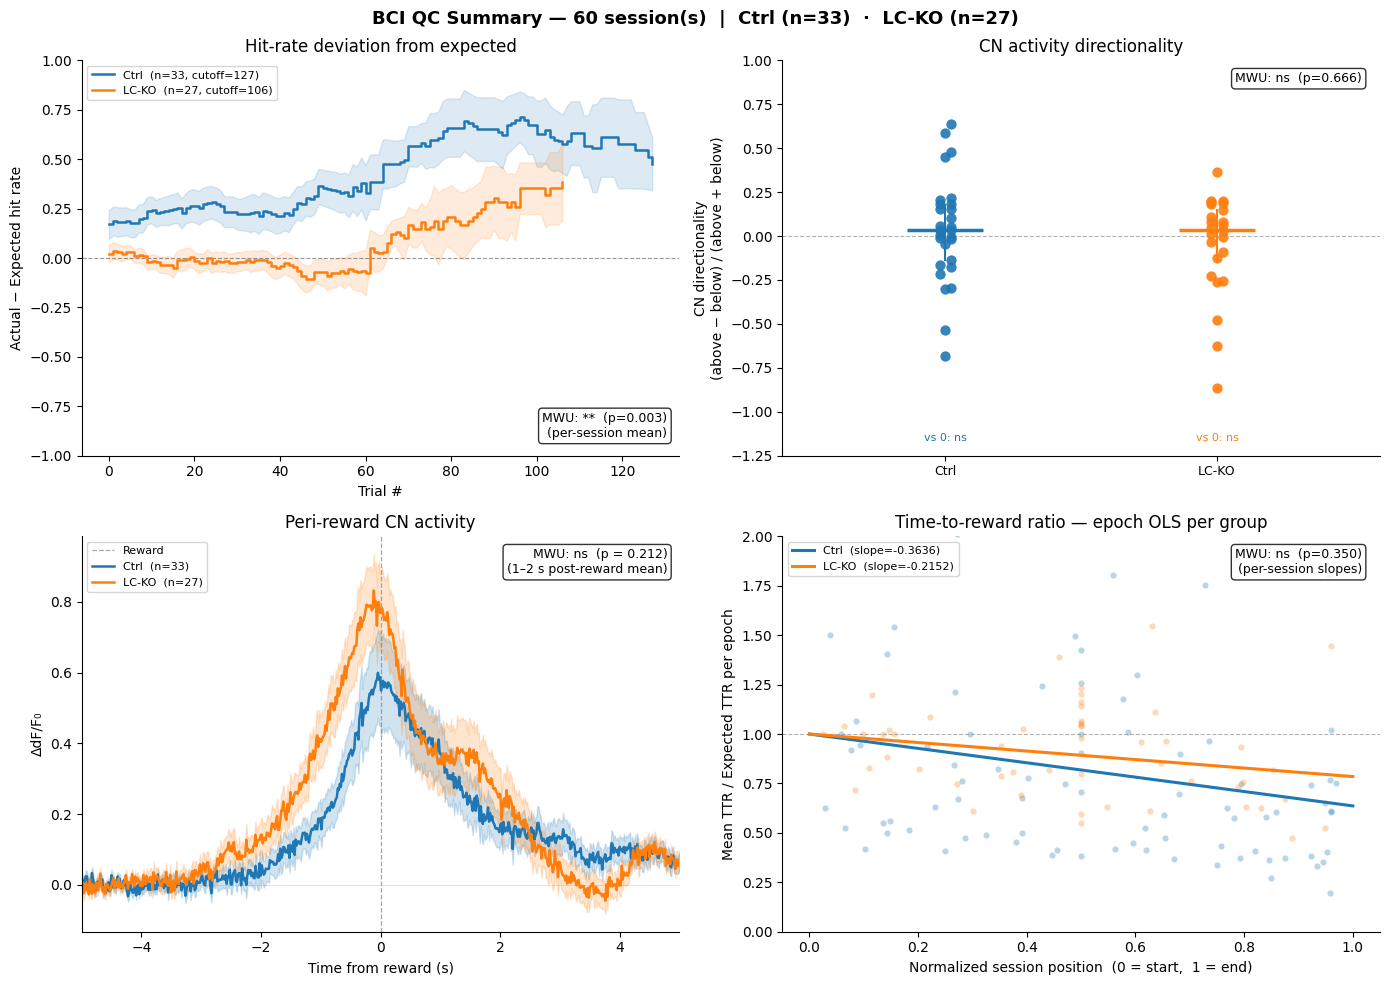


Saved → /results/figures/qc_summary.png


In [10]:
if not any(records_by_group.values()):
    print("No sessions loaded — nothing to plot.")
else:
    group_names = [g for g in GROUPS if records_by_group[g]]
    np.random.seed(42)

    n_total = sum(len(records_by_group[g]) for g in group_names)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"BCI QC Summary — {n_total} session(s)  |  "
        + "  ·  ".join(f"{g} (n={len(records_by_group[g])})" for g in group_names),
        fontsize=13, fontweight='bold',
    )

    # ── Panel 1 — Hit-rate deviation ──────────────────────────────────────────
    ax = axes[0, 0]
    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
    hd_per_group = []
    for g in group_names:
        recs = records_by_group[g];  col = GROUP_COLOR_MAP[g]
        mean_d, sem_d, n_d = pool_traces([s['hit_diff'] for s in recs])
        cutoff_idx = 0
        for idx in range(len(mean_d)):
            if n_d[idx] >= MIN_SESSIONS:
                cutoff_idx = idx
            else:
                break
        x1 = np.arange(cutoff_idx + 1)
        mean_d = mean_d[:cutoff_idx + 1];  sem_d = sem_d[:cutoff_idx + 1]
        ax.fill_between(x1, mean_d - sem_d, mean_d + sem_d,
                        alpha=0.15, color=col, where=~np.isnan(sem_d))
        ax.step(x1, mean_d, where='post', color=col, lw=1.8,
                label=f'{g}  (n={len(recs)}, cutoff={cutoff_idx})')
        hd_per_group.append([float(np.nanmean(s['hit_diff'])) for s in recs])
    p_hd, test_hd, sig_hd = between_group_test(hd_per_group)
    if test_hd != 'N/A':
        ax.text(0.98, 0.04, f'{test_hd}: {sig_hd}  (p={p_hd:.3f})\n(per-session mean)',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.set_ylim(-1, 1);  ax.set_xlabel('Trial #')
    ax.set_ylabel('Actual − Expected hit rate')
    ax.set_title('Hit-rate deviation from expected')
    ax.legend(fontsize=8, loc='upper left');  ax.spines[['top', 'right']].set_visible(False)

    # ── Panel 2 — CN directionality ───────────────────────────────────────────
    ax = axes[0, 1]
    x_centers = np.arange(len(group_names), dtype=float);  cn_per_group = []
    for xi, g in zip(x_centers, group_names):
        col     = GROUP_COLOR_MAP[g]
        metrics = np.array([s['cn_metric'] for s in records_by_group[g]
                            if not np.isnan(s['cn_metric'])])
        cn_per_group.append(metrics.tolist())
        if len(metrics) == 0:
            continue
        sorted_vals = np.sort(metrics);  x_jit = np.zeros(len(sorted_vals))
        for i in range(1, len(sorted_vals)):
            if abs(sorted_vals[i] - sorted_vals[i - 1]) < 0.08:
                x_jit[i] = -x_jit[i - 1] if x_jit[i - 1] != 0 else 0.06
        ax.scatter(xi + x_jit * 0.35, sorted_vals, color=col, s=55, alpha=0.9,
                   zorder=3, linewidths=0)
        med = np.median(metrics);  q25, q75 = np.percentile(metrics, [25, 75])
        ax.plot([xi - 0.14, xi + 0.14], [med, med], '-', color=col, lw=2.5,
                zorder=5, solid_capstyle='butt')
        ax.vlines(xi, q25, q75, lw=1.5, color=col, zorder=4)
        p_wil = np.nan
        if len(metrics) >= 4:
            try:
                _, p_wil = stats.wilcoxon(metrics, alternative='two-sided')
            except Exception:
                _, p_wil = stats.ttest_1samp(metrics, 0)
        sig_wil = ('***' if p_wil < 0.001 else '**' if p_wil < 0.01
                   else '*' if p_wil < 0.05 else 'ns' if not np.isnan(p_wil)
                   else f'N={len(metrics)}')
        ax.text(xi, -1.12, f'vs 0: {sig_wil}', ha='center', va='top', fontsize=8, color=col)
    p_cn, test_cn, sig_cn = between_group_test(cn_per_group)
    if test_cn != 'N/A':
        ax.text(0.97, 0.97, f'{test_cn}: {sig_cn}  (p={p_cn:.3f})',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.6)
    ax.set_xticks(x_centers);  ax.set_xticklabels(group_names, fontsize=9)
    ax.set_xlim(-0.6, len(group_names) - 0.4);  ax.set_ylim(-1.25, 1)
    ax.set_ylabel('CN directionality\n(above − below) / (above + below)')
    ax.set_title('CN activity directionality');  ax.spines[['top', 'right']].set_visible(False)

    # ── Panel 3 — Peri-reward ─────────────────────────────────────────────────
    ax = axes[1, 0]
    ax.axvline(0, color='gray', ls='--', lw=0.9, alpha=0.7, label='Reward')
    ax.axhline(0, color='gray', ls='-',  lw=0.4, alpha=0.4)
    peri_per_group = [];  any_peri = False
    for g in group_names:
        col = GROUP_COLOR_MAP[g]
        valid_peris = [s['peri_trace'] for s in records_by_group[g]
                       if s['peri_trace'] is not None]
        sess_means = []
        for pt in valid_peris:
            t_local = np.linspace(PLOT_SEC[0], PLOT_SEC[1], len(pt))
            sess_means.append(float(np.nanmean(pt[(t_local >= 1) & (t_local <= 2)])))
        peri_per_group.append(sess_means)
        if not valid_peris:
            continue
        any_peri = True
        mean_p, sem_p, _ = pool_traces(valid_peris)
        t_ax = np.linspace(PLOT_SEC[0], PLOT_SEC[1], len(mean_p))
        ax.fill_between(t_ax, mean_p - sem_p, mean_p + sem_p,
                        alpha=0.2, color=col, where=~np.isnan(sem_p))
        ax.plot(t_ax, mean_p, color=col, lw=1.8, label=f'{g}  (n={len(valid_peris)})')
    if not any_peri:
        ax.text(0.5, 0.5, 'No valid peri-reward data',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
    else:
        p_pr, test_pr, sig_pr = between_group_test(peri_per_group)
        if test_pr != 'N/A':
            ax.text(0.98, 0.97,
                    f'{test_pr}: {sig_pr}  (p = {p_pr:.3f})\n(1–2 s post-reward mean)',
                    transform=ax.transAxes, ha='right', va='top', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.set_xlim(PLOT_SEC);  ax.set_xlabel('Time from reward (s)')
    ax.set_ylabel('ΔdF/F₀');  ax.set_title('Peri-reward CN activity')
    ax.legend(fontsize=8);  ax.spines[['top', 'right']].set_visible(False)

    # ── Panel 4 — TTR epoch OLS ───────────────────────────────────────────────
    ax = axes[1, 1]
    ax.set_ylim(0, 2);  ax.axhline(1.0, color='gray', ls='--', lw=0.8, alpha=0.6)
    WEIGHT_BY_TRIALS = True;  x_dense = np.linspace(0, 1, 300)
    slope_per_group = []
    for g in group_names:
        recs = records_by_group[g];  col = GROUP_COLOR_MAP[g]
        slopes_g = [];  n_trials_g = []
        for s in recs:
            ratio = s['ttr_ratio'];  sw = list(s['switches']) + [len(ratio)]
            n_total = float(len(ratio));  epoch_x, epoch_y = [], []
            for ei in range(len(sw) - 1):
                ep_s = int(sw[ei]);  ep_e = int(sw[ei + 1])
                mu = float(np.nanmean(ratio[ep_s:ep_e]))
                if np.isnan(mu):
                    continue
                epoch_x.append(((ep_s + ep_e) / 2.0) / n_total);  epoch_y.append(mu)
            epoch_x = np.array(epoch_x);  epoch_y = np.array(epoch_y)
            ax.scatter(epoch_x, epoch_y, color=col, alpha=0.3, s=20, zorder=1, linewidths=0)
            n_trials_g.append(len(ratio))
            if len(epoch_x) < 2:
                ep_s = int(sw[0]);  ep_e = int(sw[1]) if len(sw) > 1 else len(ratio)
                vals = ratio[ep_s:ep_e]
                xi_n = np.arange(len(vals), dtype=float) / max(len(vals) - 1, 1)
                hit  = ~np.isnan(vals);  xi_h, yi_h = xi_n[hit], vals[hit]
                if len(xi_h) >= 4:
                    denom = float(np.dot(xi_h, xi_h))
                    slopes_g.append(float(np.dot(xi_h, yi_h - 1.0) / denom)
                                    if denom > 0 else np.nan)
                else:
                    slopes_g.append(np.nan)
                continue
            denom = float(np.dot(epoch_x, epoch_x))
            slopes_g.append(float(np.dot(epoch_x, epoch_y - 1.0) / denom)
                            if denom > 0 else np.nan)
        slopes_g = np.array(slopes_g);  n_trials_g = np.array(n_trials_g, dtype=float)
        valid_g  = ~np.isnan(slopes_g);  slope_per_group.append(slopes_g[valid_g].tolist())
        if valid_g.sum() == 0:
            continue
        w_g = n_trials_g[valid_g] ** 2 if WEIGHT_BY_TRIALS else np.ones(valid_g.sum())
        w_g /= w_g.sum();  mean_slope_g = float(np.dot(w_g, slopes_g[valid_g]))
        ax.plot(x_dense, 1.0 + mean_slope_g * x_dense, color=col, lw=2.2, zorder=3,
                label=f'{g}  (slope={mean_slope_g:+.4f})')
    p_sl, test_sl, sig_sl = between_group_test(slope_per_group)
    if test_sl != 'N/A':
        ax.text(0.97, 0.97, f'{test_sl}: {sig_sl}  (p={p_sl:.3f})\n(per-session slopes)',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.set_xlabel('Normalized session position  (0 = start,  1 = end)')
    ax.set_ylabel('Mean TTR / Expected TTR per epoch')
    ax.set_title('Time-to-reward ratio — epoch OLS per group')
    ax.legend(fontsize=8, loc='upper left');  ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    out = Path("/results/figures/qc_summary.png")
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show();  print(f"\nSaved → {out}")


<ipython-input-6-c4501300631f>:15: RuntimeWarning: Mean of empty slice
  mean  = np.nanmean(mat, axis=0)
/opt/conda/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
<ipython-input-11-39dce20a4a62>:74: RuntimeWarning: Mean of empty slice
  tc_means.append(float(np.nanmean(ep_mean[N_PRE:post_end]))


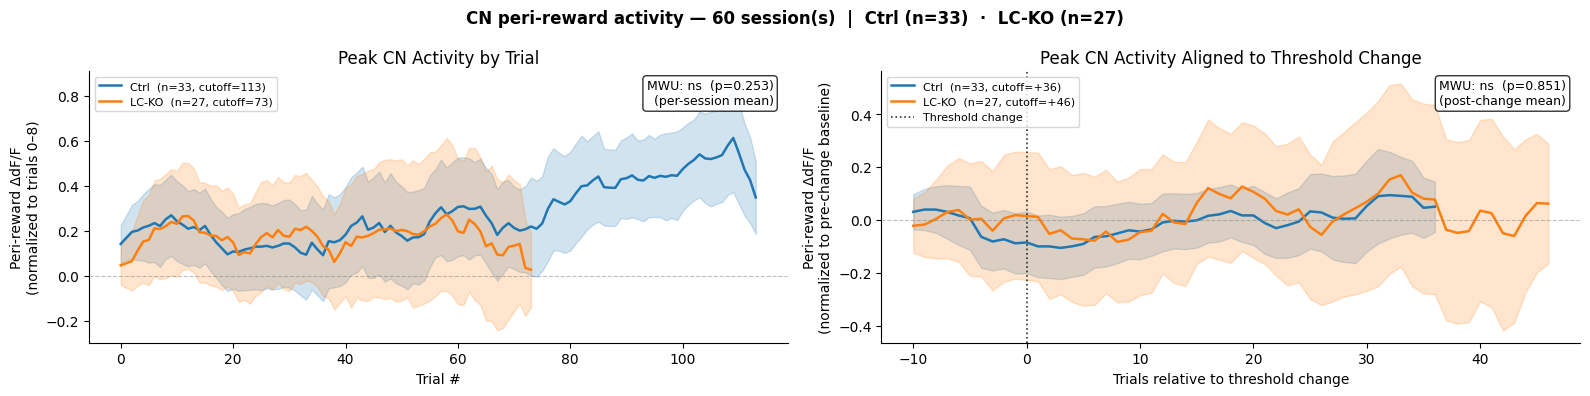

Saved → /results/figures/qc_peri_trial.png


In [11]:
# ── Figure 2: Peak CN peri-reward activity per trial ──────────────────────────
if not any(records_by_group.values()):
    print("No sessions loaded — nothing to plot.")
else:
    group_names = [g for g in GROUPS if records_by_group[g]]
    N_PRE  = 10
    n_total = sum(len(records_by_group[g]) for g in group_names)
    fig2, axes2 = plt.subplots(1, 2, figsize=(16, 4))
    fig2.suptitle(
        f"CN peri-reward activity — {n_total} session(s)  |  "
        + "  ·  ".join(f"{g} (n={len(records_by_group[g])})" for g in group_names),
        fontsize=12, fontweight='bold',
    )

    # ── Panel 2a: trial-aligned ────────────────────────────────────────────────
    ax = axes2[0];  pt_per_group = []
    for g in group_names:
        recs = records_by_group[g];  col = GROUP_COLOR_MAP[g]
        pt_traces              = [s['peri_trial_norm'] for s in recs]
        mean_pt, sem_pt, n_pt  = pool_traces(pt_traces)
        pt_per_group.append([float(np.nanmean(s['peri_trial_norm'])) for s in recs])
        if not (n_pt >= MIN_SESSIONS).any():
            continue
        cutoff_idx = 0
        for idx in range(len(mean_pt)):
            if n_pt[idx] >= MIN_SESSIONS:
                cutoff_idx = idx
            else:
                break
        x = np.arange(cutoff_idx + 1)
        mu = mean_pt[:cutoff_idx + 1];  sem = sem_pt[:cutoff_idx + 1]
        mu_sm  = np.convolve(mu,  np.ones(CN_SMOOTH) / CN_SMOOTH, mode='same')
        sem_sm = np.convolve(np.where(np.isnan(sem), 0, sem),
                             np.ones(CN_SMOOTH) / CN_SMOOTH, mode='same')
        ax.fill_between(x, mu_sm - sem_sm, mu_sm + sem_sm,
                        alpha=0.2, color=col, where=~np.isnan(sem_sm))
        ax.plot(x, mu_sm, color=col, lw=1.8,
                label=f'{g}  (n={len(recs)}, cutoff={cutoff_idx})')
    p_pt, test_pt, sig_pt = between_group_test(pt_per_group)
    if test_pt != 'N/A':
        ax.text(0.98, 0.97, f'{test_pt}: {sig_pt}  (p={p_pt:.3f})\n(per-session mean)',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_xlabel('Trial #');  ax.set_ylabel('Peri-reward ΔdF/F\n(normalized to trials 0–8)')
    ax.set_title('Peak CN Activity by Trial');  ax.legend(fontsize=8, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)

    # ── Panel 2b: threshold-change-aligned ────────────────────────────────────
    ax = axes2[1];  tc_per_group = []
    for g in group_names:
        recs = records_by_group[g];  col = GROUP_COLOR_MAP[g]
        session_rel_means = []
        for s in recs:
            pt = s['peri_trial_norm'];  sw = list(s['switches']) + [len(pt)]
            epoch_traces = []
            for i in range(len(sw) - 1):
                ep_s = int(sw[i]);  ep_e = int(sw[i + 1])
                pre = np.full(N_PRE, np.nan)
                pre_vals = pt[max(0, ep_s - N_PRE):ep_s]
                if len(pre_vals) > 0:
                    pre[-len(pre_vals):] = pre_vals
                post           = pt[ep_s:ep_e]
                baseline_epoch = float(np.nanmean(pre_vals)) if len(pre_vals) > 0 else np.nan
                epoch_traces.append(np.concatenate([pre - baseline_epoch,
                                                    post - baseline_epoch]))
            if not epoch_traces:
                session_rel_means.append(np.array([np.nan]));  continue
            ep_mean, _, _ = pool_traces(epoch_traces)
            session_rel_means.append(ep_mean)
        tc_means = []
        for ep_mean in session_rel_means:
            post_end = min(N_PRE + N_PRE, len(ep_mean))
            tc_means.append(float(np.nanmean(ep_mean[N_PRE:post_end]))
                            if post_end > N_PRE else np.nan)
        tc_per_group.append(tc_means)
        mean_rel, sem_rel, n_rel = pool_traces(session_rel_means)
        x_rel = np.arange(len(mean_rel)) - N_PRE
        post_indices = np.where(x_rel >= 0)[0]
        if (n_rel >= MIN_SESSIONS).any() and post_indices.size > 0:
            cutoff_idx = post_indices[0]
            for idx in post_indices:
                if n_rel[idx] >= MIN_SESSIONS:
                    cutoff_idx = idx
                else:
                    break
            keep    = np.arange(0, cutoff_idx + 1)
            x_plot  = x_rel[keep];  mu_plot = mean_rel[keep];  sem_plot = sem_rel[keep]
            mu_sm_r  = np.convolve(mu_plot, np.ones(CN_SMOOTH) / CN_SMOOTH, mode='same')
            sem_sm_r = np.convolve(np.where(np.isnan(sem_plot), 0, sem_plot),
                                   np.ones(CN_SMOOTH) / CN_SMOOTH, mode='same')
            ax.fill_between(x_plot, mu_sm_r - sem_sm_r, mu_sm_r + sem_sm_r,
                            alpha=0.2, color=col, where=~np.isnan(sem_sm_r))
            ax.plot(x_plot, mu_sm_r, color=col, lw=1.8,
                    label=f'{g}  (n={len(recs)}, cutoff=+{int(x_rel[cutoff_idx])})')
    p_tc, test_tc, sig_tc = between_group_test(tc_per_group)
    if test_tc != 'N/A':
        ax.text(0.98, 0.97, f'{test_tc}: {sig_tc}  (p={p_tc:.3f})\n(post-change mean)',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.axvline(0, color='k', ls=':', lw=1.2, alpha=0.8, label='Threshold change')
    ax.set_xlabel('Trials relative to threshold change')
    ax.set_ylabel('Peri-reward ΔdF/F\n(normalized to pre-change baseline)')
    ax.set_title('Peak CN Activity Aligned to Threshold Change')
    ax.legend(fontsize=8, loc='upper left');  ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    out2 = Path("/results/figures/qc_peri_trial.png")
    out2.parent.mkdir(parents=True, exist_ok=True)
    fig2.savefig(out2, dpi=150, bbox_inches='tight')
    plt.show();  print(f"Saved → {out2}")


<ipython-input-12-5374f9bd0626>:25: RuntimeWarning: Mean of empty slice
  cn_per_group_mean.append([float(np.nanmean(t)) for t in cn_sm_traces])
<ipython-input-6-c4501300631f>:15: RuntimeWarning: Mean of empty slice
  mean  = np.nanmean(mat, axis=0)


Saved → /results/figures/cn_activity.png


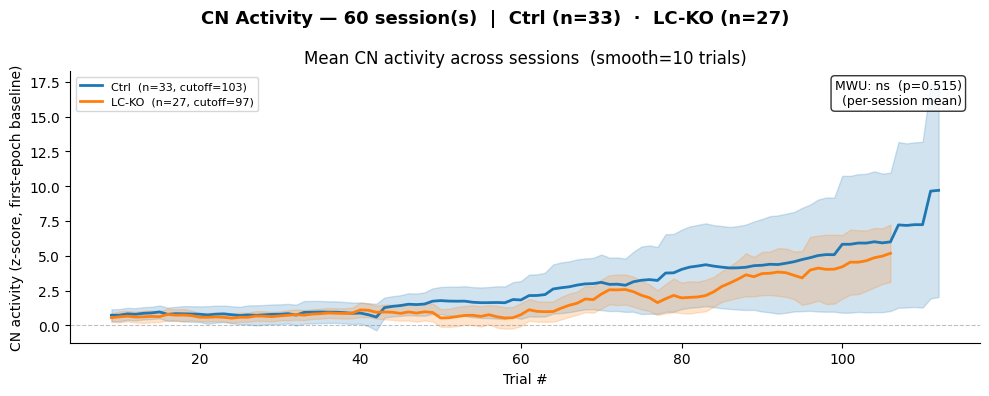

In [12]:
# ── Figure 3: Mean CN activity across sessions (z-scored, smoothed) ───────────
if not any(records_by_group.values()):
    print("No sessions loaded — nothing to plot.")
else:
    group_names = [g for g in GROUPS if records_by_group[g]]
    w = CN_SMOOTH
    n_total = sum(len(records_by_group[g]) for g in group_names)
    fig3, ax = plt.subplots(figsize=(10, 4))
    fig3.suptitle(
        f"CN Activity — {n_total} session(s)  |  "
        + "  ·  ".join(f"{g} (n={len(records_by_group[g])})" for g in group_names),
        fontsize=13, fontweight='bold',
    )
    cn_per_group_mean = []
    for g in group_names:
        recs = records_by_group[g];  col = GROUP_COLOR_MAP[g]
        cn_sm_traces = []
        for s in recs:
            raw  = np.asarray(s['cn_act_z'], dtype=float)
            nans = np.isnan(raw)
            if nans.any() and not nans.all():
                xi  = np.arange(len(raw))
                raw = np.interp(xi, xi[~nans], raw[~nans])
            cn_sm_traces.append(np.convolve(raw, np.ones(w) / w, mode='valid'))
        cn_per_group_mean.append([float(np.nanmean(t)) for t in cn_sm_traces])
        if not cn_sm_traces:
            continue
        mean_cn, sem_cn, n_cn = pool_traces(cn_sm_traces)
        cutoff_idx = 0
        for idx in range(len(mean_cn)):
            if n_cn[idx] >= MIN_SESSIONS:
                cutoff_idx = idx
            else:
                break
        x       = np.arange(w - 1, w - 1 + cutoff_idx + 1)
        mean_cn = mean_cn[:cutoff_idx + 1];  sem_cn = sem_cn[:cutoff_idx + 1]
        ax.fill_between(x, mean_cn - sem_cn, mean_cn + sem_cn,
                        alpha=0.2, color=col, where=~np.isnan(sem_cn))
        ax.plot(x, mean_cn, color=col, lw=2.0,
                label=f'{g}  (n={len(cn_sm_traces)}, cutoff={cutoff_idx})')
    p_cn3, test_cn3, sig_cn3 = between_group_test(cn_per_group_mean)
    if test_cn3 != 'N/A':
        ax.text(0.98, 0.97, f'{test_cn3}: {sig_cn3}  (p={p_cn3:.3f})\n(per-session mean)',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.set_xlabel('Trial #');  ax.set_ylabel('CN activity (z-score, first-epoch baseline)')
    ax.set_title(f'Mean CN activity across sessions  (smooth={CN_SMOOTH} trials)')
    ax.legend(fontsize=8);  ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    out3 = Path("/results/figures/cn_activity.png")
    out3.parent.mkdir(parents=True, exist_ok=True)
    fig3.savefig(out3, dpi=150, bbox_inches='tight')
    print(f"Saved → {out3}");  plt.show()


  Ctrl / 820614  2026-05-13: 57 trials
  Ctrl / 820614  2026-05-18: 17 trials
  Ctrl / 820614  2026-05-20: 47 trials
  Ctrl / 820614  2026-05-21: 36 trials
  Ctrl / 820614  2026-05-22: 72 trials
  Ctrl / 820614  2026-05-27: 26 trials
  Ctrl / 820614  2026-05-28: 31 trials
  Ctrl / 820614  2026-06-01: 130 trials
  Ctrl / 820614  2026-06-02: 70 trials
  Ctrl / 820614  2026-06-04: 126 trials
  Ctrl / 820614  2026-06-05: 46 trials
  Ctrl / 820614  2026-06-10: 48 trials
  Ctrl / 820615  2026-06-10: 26 trials
  Ctrl / 820615  2026-06-16: 24 trials
  Ctrl / 820615  2026-06-24: 29 trials
  Ctrl / 824946  2026-05-13: 3 trials
  Ctrl / 824946  2026-05-15: 81 trials
  Ctrl / 824946  2026-05-19: 2 trials
  Ctrl / 824946  2026-05-20: 21 trials
  Ctrl / 824946  2026-05-21: 93 trials
  Ctrl / 824946  2026-05-22: 5 trials
  Ctrl / 824946  2026-05-27: 14 trials
  Ctrl / 824946  2026-05-28: 50 trials
  Ctrl / 824946  2026-05-29: 39 trials
  Ctrl / 824946  2026-06-01: 23 trials
  Ctrl / 824946  2026-06-0

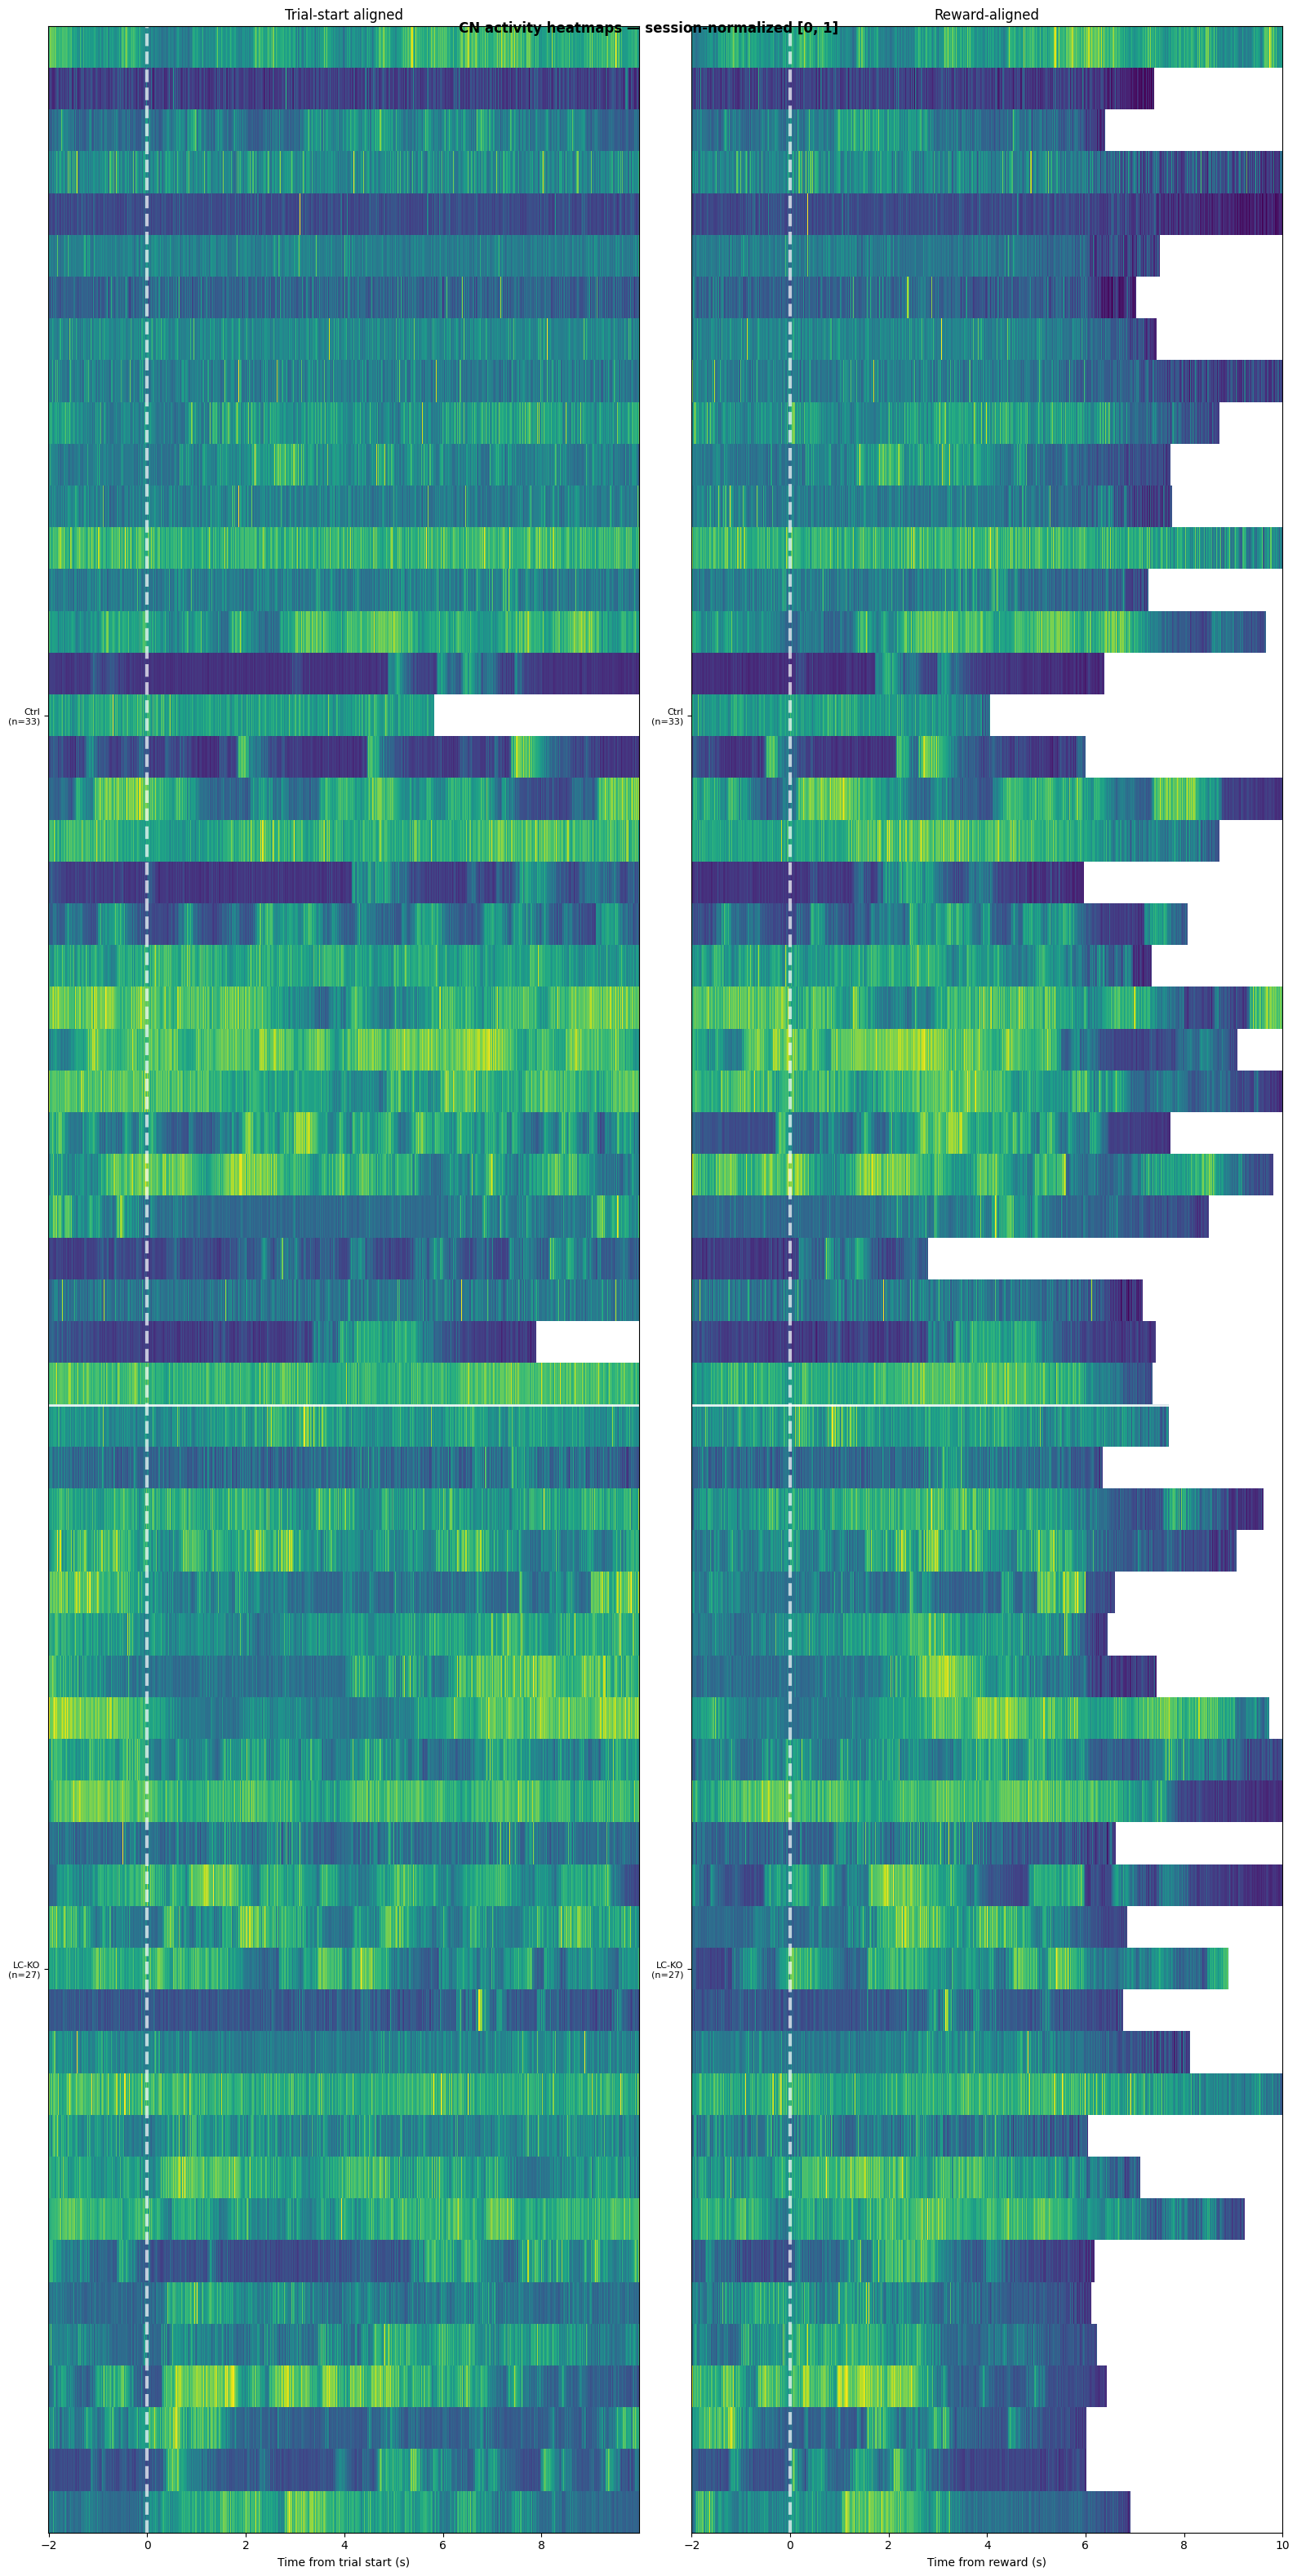

Saved → /results/figures/qc_heatmaps.png


In [13]:
# ── Figure 4: CN activity heatmaps ────────────────────────────────────────────
# Sessions are stacked by group with horizontal separators.
# Left: max-projection over trials at each within-trial timepoint (trial-start aligned).
# Right: reward-aligned max-projection, averaged across hit trials per session.
HEATMAP_PRE  = 2.0    # seconds before reward (right panel)
HEATMAP_POST = 10.0   # seconds after reward  (right panel)

if not any(records_by_group.values()):
    print("No sessions loaded — nothing to plot.")
else:
    group_names = [g for g in GROUPS if records_by_group[g]]

    # Build ordered list: all sessions from group 1, then group 2, etc.
    ordered_sessions = []    # list of (group_name, session_record)
    group_row_ranges = {}    # group_name → (start_row, end_row_exclusive)
    row = 0
    for g in group_names:
        start = row
        for s in records_by_group[g]:
            ordered_sessions.append((g, s))
            row += 1
        group_row_ranges[g] = (start, row)

    n_rows  = len(ordered_sessions)
    fs_ref  = ordered_sessions[0][1]['fs']
    hp_disp = int(HEATMAP_PRE  * fs_ref)
    hq_disp = int(HEATMAP_POST * fs_ref)
    p_len   = hp_disp + hq_disp

    # ── Trial-start-aligned matrix ────────────────────────────────────────────
    t_len      = max(len(s['cn_heat_trial']) for _, s in ordered_sessions)
    heat_trial = np.full((n_rows, t_len), np.nan)
    for i, (g, s) in enumerate(ordered_sessions):
        n = len(s['cn_heat_trial'])
        heat_trial[i, :n] = s['cn_heat_trial']

    # ── Reward-aligned matrix ─────────────────────────────────────────────────
    heat_peri = np.full((n_rows, p_len), np.nan)
    for i, (g, s) in enumerate(ordered_sessions):
        F_cn_s = s['F_norm_cn']       # (n_timepoints, n_trials)
        rt_s   = s['rew_trial_sec']   # (n_trials,) seconds within trial
        n_t    = F_cn_s.shape[0]
        hp     = int(HEATMAP_PRE  * s['fs'])
        hq     = int(HEATMAP_POST * s['fs'])
        trials = []
        for i_tr in range(F_cn_s.shape[1]):
            if np.isnan(rt_s[i_tr]):
                continue
            rf = int(rt_s[i_tr] / s['dt_si'])
            ws_raw = rf - hp;  we_raw = rf + hq
            ws = max(0, ws_raw);  we = min(n_t, we_raw)
            if ws >= we:
                continue
            seg = np.full(p_len, np.nan)
            out_start = ws - ws_raw;  out_end = out_start + (we - ws)
            seg[out_start:out_end] = F_cn_s[ws:we, i_tr]
            trials.append(seg)
        if trials:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                heat_peri[i, :] = np.nanmax(trials, axis=0)
            print(f"  {g} / {s['label']}: {len(trials)} trials")
        else:
            print(f"  {g} / {s['label']}: no valid trials")

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig4, axes4 = plt.subplots(1, 2, figsize=(16, max(4, n_rows * 0.5 + 2)))
    fig4.suptitle('CN activity heatmaps — session-normalized [0, 1]',
                  fontsize=12, fontweight='bold')

    t_ax  = ordered_sessions[0][1]['t_bci']
    t_pre = np.linspace(-HEATMAP_PRE, HEATMAP_POST, p_len)

    for ax, data_mat, x_ext, xlabel, title in [
        (axes4[0], heat_trial, [t_ax[0], t_ax[-1]], 'Time from trial start (s)', 'Trial-start aligned'),
        (axes4[1], heat_peri,  [t_pre[0], t_pre[-1]], 'Time from reward (s)',    'Reward-aligned'),
    ]:
        ax.imshow(data_mat, aspect='auto', interpolation='nearest',
                  vmin=0, vmax=1, cmap='viridis',
                  extent=[x_ext[0], x_ext[1], n_rows - 0.5, -0.5])
        ax.axvline(0, color='w', lw=3.0, ls='--', alpha=0.7)

        # Group separators and y-axis labels at group midpoints
        ytick_pos = [];  ytick_lbl = []
        for g in group_names:
            r0, r1 = group_row_ranges[g]
            if r0 > 0:
                ax.axhline(r0 - 0.5, color='w', lw=2.0, alpha=0.9)
            ytick_pos.append((r0 + r1 - 1) / 2.0)
            ytick_lbl.append(f'{g}\n(n={r1 - r0})')
        ax.set_yticks(ytick_pos)
        ax.set_yticklabels(ytick_lbl, fontsize=8)
        ax.set_xlabel(xlabel);  ax.set_title(title)

    plt.tight_layout()
    out4 = Path("/results/figures/qc_heatmaps.png")
    out4.parent.mkdir(parents=True, exist_ok=True)
    fig4.savefig(out4, dpi=150, bbox_inches='tight')
    plt.show();  print(f"Saved → {out4}")


  Ctrl / 820614  2026-05-13: best window trials 37–56  net rise=+1.2277  slope=+0.03933/trial
  Ctrl / 820614  2026-05-18: too few trials (14) — skipping
  Ctrl / 820614  2026-05-20: best window trials 20–39  net rise=+0.8322  slope=+0.00532/trial
  Ctrl / 820614  2026-05-21: best window trials 16–35  net rise=+0.1936  slope=+0.00484/trial
  Ctrl / 820614  2026-05-22: best window trials 22–41  net rise=+0.3122  slope=+0.00564/trial
  Ctrl / 820614  2026-05-27: best window trials 13–32  net rise=+0.1745  slope=+0.00524/trial
  Ctrl / 820614  2026-05-28: best window trials 5–24  net rise=+0.1274  slope=+0.00450/trial
  Ctrl / 820614  2026-06-01: best window trials 78–97  net rise=+0.4376  slope=+0.01643/trial
  Ctrl / 820614  2026-06-02: best window trials 10–29  net rise=+0.3550  slope=+0.01167/trial
  Ctrl / 820614  2026-06-04: best window trials 31–50  net rise=+0.9559  slope=+0.02610/trial
  Ctrl / 820614  2026-06-05: best window trials 40–59  net rise=+0.9523  slope=+0.01003/trial
 

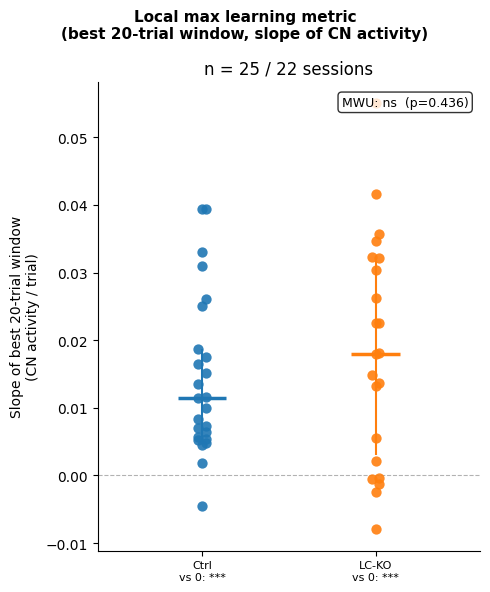


Saved → /results/figures/qc_local_learning.png


In [14]:
# ── Figure 5: Local maximum learning metric ───────────────────────────────────
# For each session: find the WIN_SIZE-trial window with the greatest net increase
# in CN activity, then report the linear regression slope of that window.
# Displayed as side-by-side beeswarms (one per group) with within- and
# between-group tests.
WIN_SIZE = 20   # consecutive trials to find best learning window

if not any(records_by_group.values()):
    print("No sessions loaded — nothing to plot.")
else:
    group_names = [g for g in GROUPS if records_by_group[g]]

    local_slopes_by_group = {g: [] for g in group_names}
    wilcoxon_sigs         = {}

    for g in group_names:
        for s in records_by_group[g]:
            trace = np.asarray(s['cn_act'][3:], dtype=float)
            n     = len(trace)
            if n < WIN_SIZE:
                print(f"  {g} / {s['label']}: too few trials ({n}) — skipping")
                continue
            net_increase = np.array([trace[i + WIN_SIZE - 1] - trace[i]
                                     for i in range(n - WIN_SIZE + 1)])
            best_i = int(np.nanargmax(net_increase))
            window = trace[best_i : best_i + WIN_SIZE]
            x_w    = np.arange(WIN_SIZE, dtype=float)
            valid  = ~np.isnan(window)
            if valid.sum() >= 4:
                res = stats.linregress(x_w[valid], window[valid])
                local_slopes_by_group[g].append(res.slope)
                print(f"  {g} / {s['label']}: best window trials "
                      f"{best_i+3}–{best_i+3+WIN_SIZE-1}  "
                      f"net rise={net_increase[best_i]:+.4f}  "
                      f"slope={res.slope:+.5f}/trial")
            else:
                print(f"  {g} / {s['label']}: insufficient valid trials — skipping")

    # Pre-compute within-group test for x-tick labels
    for g in group_names:
        slopes = np.array(local_slopes_by_group[g])
        p_wil  = np.nan
        if len(slopes) >= 3:
            try:
                fn = stats.wilcoxon if len(slopes) >= 5 else stats.ttest_1samp
                _, p_wil = (fn(slopes, alternative='two-sided')
                            if len(slopes) >= 5 else fn(slopes, 0))
            except Exception:
                pass
        wilcoxon_sigs[g] = ('***' if p_wil < 0.001 else '**' if p_wil < 0.01
                            else '*' if p_wil < 0.05 else 'ns' if not np.isnan(p_wil)
                            else f'N={len(slopes)}')

    # ── Plot ──────────────────────────────────────────────────────────────────
    x_centers = np.arange(len(group_names), dtype=float)
    ls_per_group = [local_slopes_by_group[g] for g in group_names]

    fig5, ax5 = plt.subplots(figsize=(max(5, len(group_names) * 2.5), 6))
    fig5.suptitle(f'Local max learning metric\n'
                  f'(best {WIN_SIZE}-trial window, slope of CN activity)',
                  fontsize=11, fontweight='bold')

    for xi, g in zip(x_centers, group_names):
        col    = GROUP_COLOR_MAP[g]
        slopes = np.array(local_slopes_by_group[g])
        if len(slopes) == 0:
            continue
        sorted_vals = np.sort(slopes)
        x_jit = np.zeros(len(sorted_vals))
        for i in range(1, len(sorted_vals)):
            if abs(sorted_vals[i] - sorted_vals[i - 1]) < 0.002:
                x_jit[i] = -x_jit[i - 1] if x_jit[i - 1] != 0 else 0.06
        ax5.scatter(xi + x_jit * 0.35, sorted_vals, color=col, s=55,
                    alpha=0.9, zorder=3, linewidths=0)
        med = np.median(slopes);  q25, q75 = np.percentile(slopes, [25, 75])
        ax5.plot([xi - 0.14, xi + 0.14], [med, med], '-', color=col,
                 lw=2.5, zorder=5, solid_capstyle='butt')
        ax5.vlines(xi, q25, q75, lw=1.5, color=col, zorder=4)

    # Between-group test
    p_ll, test_ll, sig_ll = between_group_test(ls_per_group)
    if test_ll != 'N/A':
        ax5.text(0.97, 0.97, f'{test_ll}: {sig_ll}  (p={p_ll:.3f})',
                 transform=ax5.transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax5.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.6)
    ax5.set_xticks(x_centers)
    # Within-group Wilcoxon result shown in x-tick label under each group name
    ax5.set_xticklabels([f'{g}\nvs 0: {wilcoxon_sigs[g]}' for g in group_names], fontsize=8)
    ax5.set_xlim(-0.6, len(group_names) - 0.4)
    ax5.set_ylabel(f'Slope of best {WIN_SIZE}-trial window\n(CN activity / trial)')
    total_n = ' / '.join(str(len(local_slopes_by_group[g])) for g in group_names)
    ax5.set_title(f'n = {total_n} sessions')
    ax5.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    out5 = Path("/results/figures/qc_local_learning.png")
    out5.parent.mkdir(parents=True, exist_ok=True)
    fig5.savefig(out5, dpi=150, bbox_inches='tight')
    plt.show();  print(f"\nSaved → {out5}")


In [15]:
# # ── Panel 4 diagnostic: toggle anchored vs free regression ───────────────────
# DEBUG_GROUP = list(GROUPS)[0];  ANCHOR_AT_ONE = False
# _recs = records_by_group[DEBUG_GROUP]
# slopes_plot = []; intercepts_plot = []; fitteds_plot = []
# for s in _recs:
#     hit_mask = ~np.isnan(s['ttr_ratio'])
#     xi = np.arange(len(s['ttr_ratio']))[hit_mask].astype(float);  yi = s['ttr_ratio'][hit_mask]
#     if ANCHOR_AT_ONE:
#         slopes_plot.append(s['slope']); intercepts_plot.append(1.0); fitteds_plot.append(s['ttr_fitted'])
#     elif len(xi) >= 2:
#         res = stats.linregress(xi, yi)
#         slopes_plot.append(res.slope); intercepts_plot.append(res.intercept)
#         fitteds_plot.append(res.intercept + res.slope * np.arange(len(s['ttr_ratio']), dtype=float))
#     else:
#         slopes_plot.append(np.nan); intercepts_plot.append(np.nan)
#         fitteds_plot.append(np.full(len(s['ttr_ratio']), np.nan))
# slopes_plot = np.array(slopes_plot); intercepts_plot = np.array(intercepts_plot)
# mean_slope = float(np.nanmean(slopes_plot)); mean_intercept = float(np.nanmean(intercepts_plot))
# valid_slopes = slopes_plot[~np.isnan(slopes_plot)]
# _, p_slope = (stats.ttest_1samp(valid_slopes, 0) if len(valid_slopes) >= 2 else (np.nan, np.nan))
# sig = '***' if p_slope < 0.001 else '**' if p_slope < 0.01 else '*' if p_slope < 0.05 else 'ns'
# x_max = max(len(f) for f in fitteds_plot); x4 = np.arange(x_max, dtype=float)
# colors = plt.cm.tab10(np.linspace(0, 0.9, len(_recs)))
# anchor_str = 'anchored Y=1' if ANCHOR_AT_ONE else 'free OLS'
# fig, ax = plt.subplots(figsize=(10, 5))
# fig.suptitle(f"P4 diag — '{DEBUG_GROUP}'  ({anchor_str})", fontsize=12, fontweight='bold')
# for s, fitted, col in zip(_recs, fitteds_plot, colors):
#     hit_mask = ~np.isnan(s['ttr_ratio']); xi = np.arange(len(s['ttr_ratio']))[hit_mask]
#     ax.scatter(xi, s['ttr_ratio'][hit_mask], color=col, alpha=0.35, s=10, zorder=1, linewidths=0)
#     ax.plot(np.arange(len(fitted)), fitted, color=col, lw=1.5, alpha=0.8, label=s['label'], zorder=2)
# ax.plot(x4, mean_intercept + mean_slope * x4, color='k', lw=2.5, ls='--', zorder=3,
#         label=f'Mean ({anchor_str})')
# ax.axhline(1.0, color='gray', ls=':', lw=0.8, alpha=0.6)
# ax.text(0.97, 0.97, f'mean slope={mean_slope:+.5f}/trial\np={p_slope:.3f} ({sig})',
#         transform=ax.transAxes, ha='right', va='top', fontsize=9)
# ax.set_xlabel('Trial #'); ax.set_ylabel('TTR / Expected TTR')
# ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
# ax.spines[['top', 'right']].set_visible(False); plt.tight_layout(); plt.show()


In [16]:
# # ── Panel 4 diagnostic: early-trial baseline normalization ────────────────────
# DEBUG_GROUP = list(GROUPS)[0];  ANCHOR_AT_ONE = True;  N_BASELINE = 10
# _recs = records_by_group[DEBUG_GROUP]
# slopes_plot = []; intercepts_plot = []; fitteds_plot = []; norm_ratio_list = []
# for s in _recs:
#     hit_mask = ~np.isnan(s['ttr_ratio']); hit_indices = np.where(hit_mask)[0]
#     if len(hit_indices) < N_BASELINE:
#         print(f"  {s['label']}: only {len(hit_indices)} hits — skipping")
#         for lst in [slopes_plot, intercepts_plot, fitteds_plot, norm_ratio_list]:
#             lst.append(np.nan if lst is not fitteds_plot and lst is not norm_ratio_list
#                        else np.full(len(s['ttr_ratio']), np.nan)); continue
#     baseline = float(np.mean(s['ttr_ratio'][hit_indices[:N_BASELINE]]))
#     norm_ratio = s['ttr_ratio'] / baseline; norm_ratio_list.append(norm_ratio)
#     xi = hit_indices.astype(float); yi = norm_ratio[hit_mask]
#     if ANCHOR_AT_ONE:
#         denom = float(np.dot(xi, xi))
#         slope = float(np.dot(xi, yi - 1.0) / denom) if denom > 0 else 0.0; intercept = 1.0
#     else:
#         res = stats.linregress(xi, yi); slope, intercept = res.slope, res.intercept
#     fitted = intercept + slope * np.arange(len(s['ttr_ratio']), dtype=float)
#     slopes_plot.append(slope); intercepts_plot.append(intercept); fitteds_plot.append(fitted)
# slopes_plot = np.array(slopes_plot); valid_slopes = slopes_plot[~np.isnan(slopes_plot)]
# mean_slope = float(np.nanmean(slopes_plot)); mean_intercept = float(np.nanmean(np.array(intercepts_plot)))
# _, p_slope = (stats.ttest_1samp(valid_slopes, 0) if len(valid_slopes) >= 2 else (np.nan, np.nan))
# sig = '***' if p_slope < 0.001 else '**' if p_slope < 0.01 else '*' if p_slope < 0.05 else 'ns'
# x_max = max(len(f) for f in fitteds_plot if hasattr(f,'__len__'))
# x4 = np.arange(x_max, dtype=float); colors = plt.cm.tab10(np.linspace(0, 0.9, len(_recs)))
# anchor_str = 'anchored Y=1' if ANCHOR_AT_ONE else 'free OLS'
# fig, ax = plt.subplots(figsize=(10, 5))
# fig.suptitle(f"P4 diag — '{DEBUG_GROUP}'  early-trial norm ({anchor_str})", fontsize=12, fontweight='bold')
# for s, nr, fitted, col in zip(_recs, norm_ratio_list, fitteds_plot, colors):
#     hit_mask = ~np.isnan(nr); xi = np.arange(len(nr))[hit_mask]
#     ax.scatter(xi, nr[hit_mask], color=col, alpha=0.35, s=10, zorder=1, linewidths=0)
#     ax.plot(np.arange(len(fitted)), fitted, color=col, lw=1.5, alpha=0.8, label=s['label'], zorder=2)
# ax.plot(x4, mean_intercept + mean_slope * x4, color='k', lw=2.5, ls='--', zorder=3)
# ax.axhline(1.0, color='gray', ls=':', lw=0.8, alpha=0.6)
# ax.text(0.97, 0.97, f'mean slope={mean_slope:+.5f}/trial\np={p_slope:.3f} ({sig})',
#         transform=ax.transAxes, ha='right', va='top', fontsize=9)
# ax.set_xlabel('Trial #'); ax.set_ylabel(f'TTR / Mean first-{N_BASELINE}-hit TTR')
# ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
# ax.spines[['top', 'right']].set_visible(False); plt.tight_layout(); plt.show()


In [17]:
# # ── Panel 4 diagnostic: power law + linear anchored epoch fit ─────────────────
# from scipy.optimize import curve_fit
# DEBUG_GROUP = list(GROUPS)[0];  _recs = records_by_group[DEBUG_GROUP]
# def power_law_norm(x, b): return (1.0 + x) ** b
# def linear_anchored(x, slope): return 1.0 + slope * x
# colors = plt.cm.tab10(np.linspace(0, 0.9, len(_recs)));  x_dense = np.linspace(0, 1, 300)
# session_fits = [];  fig, ax = plt.subplots(figsize=(11, 5))
# fig.suptitle(f"P4 diag — '{DEBUG_GROUP}'  normalized epoch fit", fontsize=12, fontweight='bold')
# for s, col in zip(_recs, colors):
#     ratio = s['ttr_ratio'];  sw = list(s['switches']) + [len(ratio)];  n_total = float(len(ratio))
#     fits = dict(label=s['label'], n_epochs=len(sw)-1, lin=np.nan, pow=np.nan, fallback=False)
#     epoch_x, epoch_y, epoch_n = [], [], []
#     for ei in range(len(sw) - 1):
#         ep_s = int(sw[ei]);  ep_e = int(sw[ei + 1]);  vals = ratio[ep_s:ep_e]
#         mu = float(np.nanmean(vals))
#         if np.isnan(mu): continue
#         epoch_x.append(((ep_s+ep_e)/2.)/n_total); epoch_y.append(mu); epoch_n.append(ep_e-ep_s)
#     epoch_x=np.array(epoch_x); epoch_y=np.array(epoch_y); epoch_n=np.array(epoch_n,dtype=float)
#     ax.scatter(epoch_x,epoch_y,color=col,alpha=0.8,zorder=3,s=epoch_n*3,linewidths=0.5,edgecolors='white')
#     ax.plot(epoch_x,epoch_y,color=col,alpha=0.35,lw=1.0,zorder=2)
#     if len(epoch_x)<2:
#         ep_s=int(sw[0]); ep_e=int(sw[1]) if len(sw)>1 else len(ratio); vals=ratio[ep_s:ep_e]
#         xi=np.arange(len(vals),dtype=float); xi_n=xi/max(xi[-1],1.); hit_mask=~np.isnan(vals)
#         xi_n_hit=xi_n[hit_mask]; yi_hit=vals[hit_mask]
#         if len(xi_n_hit)>=4:
#             fits['fallback']=True; denom=float(np.dot(xi_n_hit,xi_n_hit))
#             if denom>0: fits['lin']=float(np.dot(xi_n_hit,yi_hit-1.)/denom)
#             try:
#                 popt,_=curve_fit(power_law_norm,xi_n_hit,yi_hit,p0=[-0.3],maxfev=10000); fits['pow']=float(popt[0])
#                 ax.plot(x_dense,power_law_norm(x_dense,fits['pow']),color=col,lw=0.8,alpha=0.25,ls=':',zorder=2)
#             except Exception as e: print(f"  Fallback pow failed: {e}")
#         session_fits.append(fits); continue
#     y_shifted=epoch_y-1.; denom=float(np.dot(epoch_x,epoch_x))
#     if denom>0: fits['lin']=float(np.dot(epoch_x,y_shifted)/denom)
#     try:
#         popt,_=curve_fit(power_law_norm,epoch_x,epoch_y,p0=[-0.3],maxfev=10000); fits['pow']=float(popt[0])
#     except Exception as e: print(f"  Power law failed: {e}")
#     session_fits.append(fits)
# for f,col in zip(session_fits,colors):
#     if not np.isnan(f['pow']): ax.plot(x_dense,power_law_norm(x_dense,f['pow']),color=col,lw=0.8,alpha=0.25,ls=':' if f['fallback'] else '-',zorder=2)
# pow_bs=np.array([f['pow'] for f in session_fits if not np.isnan(f['pow'])])
# lin_slopes=np.array([f['lin'] for f in session_fits if not np.isnan(f['lin'])])
# if len(pow_bs)>0: ax.plot(x_dense,power_law_norm(x_dense,float(np.mean(pow_bs))),color='seagreen',lw=2.5,zorder=4,label=f'Power law mean b={np.mean(pow_bs):.3f}')
# if len(lin_slopes)>0: ax.plot(x_dense,linear_anchored(x_dense,float(np.mean(lin_slopes))),color='steelblue',lw=2.5,ls='--',zorder=4,label=f'Linear mean slope={np.mean(lin_slopes):.3f}')
# ax.axhline(1.,color='gray',ls=':',lw=0.8,alpha=0.6,label='Y=1  (on target)')
# ax.set_xlim(-0.02,1.05); ax.set_xlabel('Normalized session position'); ax.set_ylabel('Mean TTR/Expected TTR per epoch')
# ax.legend(fontsize=9,loc='upper right'); ax.spines[['top','right']].set_visible(False); plt.tight_layout(); plt.show()


In [18]:
# # ── CN metric debug: step-by-step for one session ─────────────────────────────
# DEBUG_GROUP = list(GROUPS)[0];  DEBUG_SESSION_IDX = 0
# s = records_by_group[DEBUG_GROUP][DEBUG_SESSION_IDX]
# trace = np.asarray(s['cn_act'], dtype=float)[3:];  x_raw = np.arange(3, 3+len(trace))
# nans = np.isnan(trace)
# if nans.any():
#     x_all = np.arange(len(trace)); trace = np.interp(x_all, x_all[~nans], trace[~nans])
# smoothed = np.convolve(trace, np.ones(CN_SMOOTH)/CN_SMOOTH, mode='valid')
# offset = (CN_SMOOTH-1)//2;  x_sm = np.arange(offset, offset+len(smoothed))
# deriv = np.diff(smoothed);  x_deriv = x_sm[:-1]+0.5
# above = deriv[deriv>0].sum();  below = np.abs(deriv[deriv<0]).sum()
# total = above+below;  metric = (above-below)/total if total>0 else 0.
# _col = GROUP_COLOR_MAP[DEBUG_GROUP]
# fig, axes_d = plt.subplots(2, 1, figsize=(11, 7))
# fig.suptitle(f"CN metric debug — {s['label']}  [{DEBUG_GROUP}]  |  CN_SMOOTH={CN_SMOOTH}  |  metric={metric:+.3f}",
#              fontsize=12, fontweight='bold')
# ax = axes_d[0]
# ax.plot(x_raw, trace, color='lightgray', lw=0.8, label='Raw')
# ax.plot(x_sm, smoothed, color=_col, lw=1.8, label=f'Smoothed (window={CN_SMOOTH})')
# ax.set_ylabel('CN activity (mean dF/F per trial)');  ax.set_title('Step 1 — smooth')
# ax.legend(fontsize=9);  ax.spines[['top','right']].set_visible(False)
# ax = axes_d[1]
# ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5);  ax.plot(x_deriv, deriv, color='k', lw=1.)
# ax.fill_between(x_deriv, deriv, 0, where=(deriv>0), color='seagreen', alpha=0.5, label=f'Above 0 (Σ={above:.3f})')
# ax.fill_between(x_deriv, deriv, 0, where=(deriv<0), color='tomato',   alpha=0.5, label=f'Below 0 (Σ={below:.3f})')
# ax.set_xlabel('Trial #');  ax.set_ylabel('Δ CN activity / trial')
# ax.set_title(f'Step 2 — (above−below)/(above+below) = ({above:.3f}−{below:.3f})/{total:.3f} = {metric:+.3f}')
# ax.legend(fontsize=9);  ax.spines[['top','right']].set_visible(False)
# plt.tight_layout();  plt.show()


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# INSPECT CELL — extract per-session features → CSV
# Paste this anywhere after records_by_group is populated and the trial-window
# restriction cell has run.  Requires: numpy, scipy, pandas (all available in CO).
# Output: /results/bci_session_features.csv
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats as _stats

_WIN_SIZE = 20    # local-max window (match Fig 5 WIN_SIZE)
_N_THIRDS = 3     # how many equal parts to split each session into

rows = []

for _group, _recs in records_by_group.items():
    for _s in _recs:

        # ── Identity ──────────────────────────────────────────────────────────
        _parts   = _s['label'].split()
        _subject = _parts[0] if _parts else ''
        _date    = _parts[1] if len(_parts) > 1 else ''

        # ── Core arrays (windowed, after trial restriction) ───────────────────
        _ttr      = np.asarray(_s['ttr_ratio'],       dtype=float)   # NaN = miss
        _cn_z     = np.asarray(_s['cn_act_z'],        dtype=float)
        _cn_raw   = np.asarray(_s['cn_act'],          dtype=float)
        _peri_tr  = np.asarray(_s['peri_trial_norm'], dtype=float)
        _hdiff    = np.asarray(_s['hit_diff'],         dtype=float)
        _sw       = list(_s['switches'])

        _n        = len(_ttr)
        _hit_mask = ~np.isnan(_ttr)
        _n_hits   = int(_hit_mask.sum())

        # ── Session-level scalars ─────────────────────────────────────────────
        _overall_hr = _n_hits / _n if _n > 0 else np.nan

        # ── Hit rate by position ──────────────────────────────────────────────
        _third = max(_n // _N_THIRDS, 1)

        def _safe_mean(arr):
            a = np.asarray(arr, dtype=float)
            return float(np.nanmean(a)) if len(a) > 0 else np.nan

        _hr_f10 = _safe_mean(_hit_mask[:10])  if _n >= 10 else np.nan
        _hr_l10 = _safe_mean(_hit_mask[-10:]) if _n >= 10 else np.nan
        _hr_f3  = _safe_mean(_hit_mask[:_third])
        _hr_l3  = _safe_mean(_hit_mask[-_third:])

        # ── TTR ratio by epoch ────────────────────────────────────────────────
        _epoch_edges = _sw + [_n]
        _epoch_ttr   = []
        for _ei in range(len(_epoch_edges) - 1):
            _ep_s, _ep_e = int(_epoch_edges[_ei]), int(_epoch_edges[_ei + 1])
            _epoch_ttr.append(_safe_mean(_ttr[_ep_s:_ep_e]))

        _ttr_ep1   = _epoch_ttr[0]  if _epoch_ttr else np.nan
        _ttr_epl   = _epoch_ttr[-1] if _epoch_ttr else np.nan
        _ttr_delta = (_ttr_epl - _ttr_ep1) if (not np.isnan(_ttr_ep1) and
                                                 not np.isnan(_ttr_epl)) else np.nan

        # Overall median & quartile comparison (robust to outliers)
        _hit_ttr     = _ttr[_hit_mask]
        _ttr_median  = float(np.nanmedian(_hit_ttr)) if len(_hit_ttr) > 0 else np.nan
        _q_idx       = _n // 4
        _ttr_q1_med  = float(np.nanmedian(_ttr[:_q_idx]))          if _q_idx > 0 else np.nan
        _ttr_q4_med  = float(np.nanmedian(_ttr[_n - _q_idx:]))     if _q_idx > 0 else np.nan
        _ttr_q_delta = (_ttr_q4_med - _ttr_q1_med) if (not np.isnan(_ttr_q1_med) and
                                                         not np.isnan(_ttr_q4_med)) else np.nan

        # ── CN activity by position ───────────────────────────────────────────
        _cn_f3    = _safe_mean(_cn_z[:_third])
        _cn_l3    = _safe_mean(_cn_z[-_third:])
        _cn_delta = (_cn_l3 - _cn_f3) if (not np.isnan(_cn_f3) and
                                            not np.isnan(_cn_l3)) else np.nan

        # ── Peri-reward activity in the 1–2 s test window (Panel 3) ──────────
        _peri_trace = _s.get('peri_trace')
        _peri_1_2s  = np.nan
        if _peri_trace is not None and len(_peri_trace) > 0:
            _t_local   = np.linspace(PLOT_SEC[0], PLOT_SEC[1], len(_peri_trace))
            _peri_1_2s = _safe_mean(_peri_trace[(_t_local >= 1) & (_t_local <= 2)])

        # ── Local-max learning slope (recomputes inline → no Fig 5 dependency) ─
        _trace_lm            = _cn_raw[3:]   # skip first 3 (artefact guard, same as Fig 5)
        _n_lm                = len(_trace_lm)
        _local_slope         = np.nan
        _best_win_start      = np.nan
        _best_win_net_rise   = np.nan
        _best_win_cn_mean    = np.nan
        if _n_lm >= _WIN_SIZE:
            _net = np.array([_trace_lm[_i + _WIN_SIZE - 1] - _trace_lm[_i]
                             for _i in range(_n_lm - _WIN_SIZE + 1)])
            _bi  = int(np.nanargmax(_net))
            _win = _trace_lm[_bi : _bi + _WIN_SIZE]
            _xw  = np.arange(_WIN_SIZE, dtype=float)
            _vld = ~np.isnan(_win)
            if _vld.sum() >= 4:
                _res             = _stats.linregress(_xw[_vld], _win[_vld])
                _local_slope     = float(_res.slope)
                _best_win_start  = int(_bi + 3)        # re-add the 3-trial offset
                _best_win_net_rise = float(_net[_bi])
                _best_win_cn_mean  = float(np.nanmean(_win))

        # ── Time-to-first-learning (first trial where TTR ratio < 0.8) ────────
        _below08 = np.where(_ttr < 0.8)[0]
        _time_to_learn = int(_below08[0]) if len(_below08) > 0 else np.nan

        # ── Peri-reward trial-level trend (does it improve?) ─────────────────
        _pt_hit  = _peri_tr[_hit_mask]
        _pt_corr = np.nan
        if len(_pt_hit) >= 4:
            _xi  = np.arange(len(_pt_hit), dtype=float)
            _vld = ~np.isnan(_pt_hit)
            if _vld.sum() >= 4:
                try:
                    _r, _ = _stats.pearsonr(_xi[_vld], _pt_hit[_vld])
                    _pt_corr = float(_r)
                except Exception:
                    pass

        rows.append(dict(
            # Identity
            group               = _group,
            subject             = _subject,
            date                = _date,

            # Session shape
            n_trials            = _n,
            n_hits              = _n_hits,
            n_epochs            = len(_epoch_ttr),
            fs_hz               = float(_s['fs']),

            # ── Hit-rate metrics ──────────────────────────────────────
            hit_rate_overall    = _overall_hr,
            hit_rate_first_10   = _hr_f10,
            hit_rate_last_10    = _hr_l10,
            hit_rate_change_10  = (_hr_l10 - _hr_f10) if not (np.isnan(_hr_f10) or np.isnan(_hr_l10)) else np.nan,
            hit_rate_first_3rd  = _hr_f3,
            hit_rate_last_3rd   = _hr_l3,
            hit_rate_change_3rd = (_hr_l3 - _hr_f3) if not (np.isnan(_hr_f3) or np.isnan(_hr_l3)) else np.nan,
            mean_hit_diff       = _safe_mean(_hdiff),   # deviation from expected

            # ── TTR ratio metrics ─────────────────────────────────────
            ttr_ratio_epoch1    = _ttr_ep1,             # baseline performance
            ttr_ratio_last_ep   = _ttr_epl,             # end-of-session performance
            ttr_ratio_delta_ep  = _ttr_delta,           # epoch1→last (neg = improvement)
            ttr_ratio_median    = _ttr_median,           # overall (robust)
            ttr_ratio_q1_med    = _ttr_q1_med,          # first-quarter median
            ttr_ratio_q4_med    = _ttr_q4_med,          # last-quarter median
            ttr_ratio_q_delta   = _ttr_q_delta,         # q4−q1 (neg = improvement)
            ttr_slope_anchored  = float(_s['slope']),   # Panel 4 OLS slope
            time_to_learn_trial = _time_to_learn,       # first trial with ratio < 0.8

            # ── CN activity metrics ───────────────────────────────────
            cn_directionality   = float(_s['cn_metric']),  # Panel 2
            cn_act_z_mean       = _safe_mean(_cn_z),
            cn_act_z_first_3rd  = _cn_f3,
            cn_act_z_last_3rd   = _cn_l3,
            cn_act_z_delta      = _cn_delta,            # pos = increased over session
            peri_reward_1_2s    = _peri_1_2s,           # Panel 3 test window
            mean_peri_trial     = _safe_mean(_peri_tr),
            peri_trial_corr     = _pt_corr,             # trend of peri-rew across hits

            # ── Local-max learning (Fig 5) ────────────────────────────
            local_max_slope     = _local_slope,
            best_win_start      = _best_win_start,      # trial where peak learning begins
            best_win_net_rise   = _best_win_net_rise,   # magnitude of best window rise
            best_win_cn_mean    = _best_win_cn_mean,    # CN level during best window
        ))

# ── Build DataFrame ───────────────────────────────────────────────────────────
df_inspect = pd.DataFrame(rows)

# ── Save CSV ──────────────────────────────────────────────────────────────────
_out = Path('/results/bci_session_features.csv')
_out.parent.mkdir(parents=True, exist_ok=True)
df_inspect.to_csv(_out, index=False, float_format='%.6g')
print(f"✓  Saved {len(df_inspect)} sessions → {_out}\n")

# ── Quick group-level preview ─────────────────────────────────────────────────
_key_cols = [
    'hit_rate_overall', 'hit_rate_change_10',
    'ttr_ratio_epoch1', 'ttr_ratio_delta_ep', 'ttr_slope_anchored',
    'cn_directionality', 'peri_reward_1_2s',
    'cn_act_z_delta', 'local_max_slope', 'time_to_learn_trial',
]
print("Per-group means (± std):")
print(df_inspect.groupby('group')[_key_cols]
      .agg(lambda x: f"{x.mean():.3f} ± {x.std():.3f}")
      .T.to_string())
print()

print("Per-session table:")
display(df_inspect)

✓  Saved 60 sessions → /results/bci_session_features.csv

Per-group means (± std):
group                          Ctrl           LC-KO
hit_rate_overall      0.791 ± 0.298   0.789 ± 0.169
hit_rate_change_10   -0.086 ± 0.251  -0.142 ± 0.278
ttr_ratio_epoch1      0.994 ± 0.530   0.948 ± 0.200
ttr_ratio_delta_ep   -0.100 ± 0.272  -0.018 ± 0.153
ttr_slope_anchored    0.001 ± 0.008  -0.000 ± 0.004
cn_directionality     0.034 ± 0.300  -0.045 ± 0.287
peri_reward_1_2s      0.244 ± 0.347   0.338 ± 0.428
cn_act_z_delta        0.313 ± 3.521  -0.250 ± 1.633
local_max_slope       0.014 ± 0.012   0.018 ± 0.017
time_to_learn_trial  6.107 ± 11.036   3.296 ± 6.151

Per-session table:


<ipython-input-19-8bf36942c8f7>:45: RuntimeWarning: Mean of empty slice
  return float(np.nanmean(a)) if len(a) > 0 else np.nan
<ipython-input-19-8bf36942c8f7>:68: RuntimeWarning: All-NaN slice encountered
  _ttr_q1_med  = float(np.nanmedian(_ttr[:_q_idx]))          if _q_idx > 0 else np.nan
<ipython-input-19-8bf36942c8f7>:69: RuntimeWarning: All-NaN slice encountered
  _ttr_q4_med  = float(np.nanmedian(_ttr[_n - _q_idx:]))     if _q_idx > 0 else np.nan


,group,subject,date,n_trials,n_hits,n_epochs,fs_hz,hit_rate_overall,hit_rate_first_10,hit_rate_last_10,...,cn_act_z_first_3rd,cn_act_z_last_3rd,cn_act_z_delta,peri_reward_1_2s,mean_peri_trial,peri_trial_corr,local_max_slope,best_win_start,best_win_net_rise,best_win_cn_mean
0,Ctrl,820614,2026-05-13,60,57,3,58.290074,0.950000,0.9,1.0,...,0.006490,1.873347,1.866857,0.008916,0.804244,0.466728,0.039334,37.0,1.227651,1.899585
1,Ctrl,820614,2026-05-18,17,0,2,58.290074,0.000000,0.0,0.0,...,0.980270,1.883644,0.903373,-0.033598,0.059119,NaN,NaN,NaN,NaN,NaN
2,Ctrl,820614,2026-05-20,49,47,3,58.290074,0.959184,1.0,0.8,...,-1.186675,-0.562212,0.624462,-0.098605,-0.491184,0.241241,0.005318,20.0,0.832188,1.317850
3,Ctrl,820614,2026-05-21,43,38,2,58.290074,0.883721,1.0,0.5,...,-1.569947,-9.045890,-7.475943,0.073133,-0.023559,0.181445,0.004843,16.0,0.193645,0.499672
4,Ctrl,820614,2026-05-22,75,74,4,58.290074,0.986667,1.0,0.9,...,1.284027,1.976583,0.692556,0.037626,0.131796,-0.110134,0.005639,22.0,0.312201,0.646668
5,Ctrl,820614,2026-05-27,33,27,1,58.290074,0.818182,0.9,0.9,...,-1.198657,-1.058231,0.140426,0.119662,-1.102690,-0.159108,0.005237,13.0,0.174487,1.746711
6,Ctrl,820614,2026-05-28,35,31,3,58.290074,0.885714,0.7,1.0,...,1.754267,3.582427,1.828159,0.002788,0.231002,0.430572,0.004497,5.0,0.127377,0.173831
7,Ctrl,820614,2026-06-01,137,132,8,58.290074,0.963504,1.0,0.7,...,11.576043,27.343244,15.767201,-0.016633,0.618781,0.740501,0.016428,78.0,0.437569,1.156800
8,Ctrl,820614,2026-06-02,74,71,4,58.290074,0.959459,1.0,0.9,...,0.455673,0.736216,0.280543,0.060715,0.057125,0.118432,0.011669,10.0,0.355041,0.331099
9,Ctrl,820614,2026-06-04,128,128,7,58.290074,1.000000,1.0,1.0,...,0.498989,1.928817,1.429828,0.434344,0.304495,0.218896,0.026102,31.0,0.955860,1.309061
